Replica de articulo https://www.quantconnect.com/research/18987/portfolio-construction-using-topological-data-analysis/p1 

# Librerías

In [1]:
import pandas as pd
import numpy as np
import random

import plotly
import requests
from bs4 import BeautifulSoup
import ruptures as rpt
import yfinance as yf

import plotly.graph_objects as go
import matplotlib.pyplot as plt

import kmapper as km
import subprocess
import sys
import networkx as nx
subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly", "nbformat>=4.2.0"])
import sklearn.cluster

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.cluster import DBSCAN, KMeans
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots


# Datos

## Sacar tickers

In [2]:

# URL de la lista del S&P 500
url = "https://www.slickcharts.com/sp500"


# Hacer la petición con headers para evitar bloqueos
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
}
response = requests.get(url, headers=headers)
response.raise_for_status()  # Raise exception for bad status codes

# Parsear el HTML
soup = BeautifulSoup(response.text, 'html.parser')

# Encontrar la tabla
table = soup.find('table')

if table:
    # Leer la tabla con pandas
    df = pd.read_html(str(table))[0]
    
    # Extraer los tickers
    if 'Symbol' in df.columns:
        tickers = df['Symbol'].tolist()
        print(f"Found {len(tickers)} tickers")
        print("First 10 tickers:", tickers[:10])
    else:
        print("Available columns:", df.columns.tolist())

    # Extraer los pesos
    if 'Weight' in df.columns:
        weights = df['Weight'].tolist()
        print(f"Found {len(weights)} weights")
        print("First 10 weights:", weights[:10])
    else:
        print("Available columns:", df.columns.tolist())
else:
    print("No table found on the page")

# En la lista de ticker, reemplazar los "." por "-"
tickers = [ticker.replace('.', '-') for ticker in tickers]
print("Tickers after replacement:", tickers[:10])

Found 503 tickers
First 10 tickers: ['NVDA', 'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'GOOG', 'AVGO', 'META', 'TSLA', 'BRK.B']
Found 503 weights
First 10 weights: ['7.52%', '6.69%', '6.06%', '3.97%', '3.07%', '2.87%', '2.75%', '2.47%', '2.24%', '1.80%']
Tickers after replacement: ['NVDA', 'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'GOOG', 'AVGO', 'META', 'TSLA', 'BRK-B']


## Historicos

In [3]:
START_DATE='2015-01-01'
END_DATE='2025-11-01'
AN_DATE='2024-01-01'

In [4]:
# -----------------------------
# -----------------------------
# Descargar precios históricos
# -----------------------------
all_tickers_data = yf.download(tickers, start=START_DATE, end=END_DATE, auto_adjust=True)['Close']
all_tickers_data = all_tickers_data.dropna(axis=1)  # eliminar columnas con datos faltantes

# DIVIDIR EN DOS PERIODOS
# Período de análisis: desde START_DATE hasta AN_DATE
analysis_data = all_tickers_data.loc[START_DATE:AN_DATE]
tickers_data = analysis_data  # Datos para entrenamiento/análisis

# Período de validación: desde AN_DATE hasta END_DATE
validation_data = all_tickers_data.loc[AN_DATE:END_DATE]  # Datos para validación

print(f"✅ Datos descargados:")
print(f"   📊 Total: {all_tickers_data.shape} (desde {START_DATE} hasta {END_DATE})")
print(f"   📊 Período de análisis: {tickers_data.shape} (desde {START_DATE} hasta {AN_DATE})")
print(f"   📊 Período de validación: {validation_data.shape} (desde {AN_DATE} hasta {END_DATE})")

[*********************100%***********************]  503 of 503 completed


✅ Datos descargados:
   📊 Total: (2725, 463) (desde 2015-01-01 hasta 2025-11-01)
   📊 Período de análisis: (2264, 463) (desde 2015-01-01 hasta 2024-01-01)
   📊 Período de validación: (461, 463) (desde 2024-01-01 hasta 2025-11-01)


In [5]:
## Datos S&P500
# Descargar SPY para benchmark
SPY_data = yf.download('SPY', start=START_DATE, end=END_DATE, auto_adjust=True)['Close']

# Verificar si es Serie o DataFrame y convertir apropiadamente
if isinstance(SPY_data, pd.Series):
    SPY = SPY_data.to_frame(name='SPY')
else:
    # Si ya es DataFrame, asegurarse que la columna se llame 'SPY'
    SPY = SPY_data.to_frame() if len(SPY_data.shape) == 1 else SPY_data
    if 'SPY' not in SPY.columns:
        SPY.columns = ['SPY']

# Dividir en períodos
SPY_analysis = SPY.loc[START_DATE:AN_DATE]
SPY_validation = SPY.loc[AN_DATE:END_DATE]

print(f"✅ SPY descargado:")
print(f"   📊 SPY_analysis: {SPY_analysis.shape}")
print(f"   📊 SPY_validation: {SPY_validation.shape}")
print(f"   📋 Columnas: {SPY_analysis.columns.tolist()}")

[*********************100%***********************]  1 of 1 completed

✅ SPY descargado:
   📊 SPY_analysis: (2264, 1)
   📊 SPY_validation: (461, 1)
   📋 Columnas: ['SPY']


## Info financiera

In [6]:
from datetime import timedelta
import pandas as pd

def marketcap_en_fecha(ticker, fecha):
    # Convert string to datetime if needed
    if isinstance(fecha, str):
        fecha = pd.to_datetime(fecha)
    
    t = yf.Ticker(ticker)
    
    # Use a wider date range to ensure data availability
    fecha_inicio = fecha - timedelta(days=7)  # Look back 7 days
    
    # Get historical data
    history = t.history(start=fecha_inicio, end=fecha)
    shares = t.get_shares_full(start=fecha_inicio, end=fecha)
    
    # Validate data exists
    if history.empty or 'Close' not in history.columns:
        raise ValueError(f"No price data for {ticker} around {fecha}")
    if shares.empty:
        raise ValueError(f"No shares data for {ticker} around {fecha}")
    
    # Get the closest available data to the target date
    price = history["Close"].iloc[-1]  # Most recent price
    shares_count = shares.iloc[-1]     # Most recent share count
    
    return price * shares_count

# Example usage
marketcap_en_fecha("AVGO", AN_DATE)

51197756419.65918

In [7]:
# =======================================================
# 📊 RECOPILACIÓN DE INFORMACIÓN FUNDAMENTAL DE TICKERS
# =======================================================

import os

# Verificar si el archivo ya existe
csv_filename = 'sp500_ticker_info_database.csv'

if os.path.exists(csv_filename):
    # ✅ ARCHIVO EXISTE - Cargar datos existentes
    print("✅ Archivo 'sp500_ticker_info_database.csv' encontrado")
    print("📂 Cargando información desde archivo guardado...")
    print("=" * 80)
    
    try:
        ticker_info_df = pd.read_csv(csv_filename, index_col=0)
        
        # Convertir DataFrame a diccionario para ticker_info_db
        ticker_info_db = ticker_info_df.to_dict('index')
        
        print(f"✅ Datos cargados exitosamente")
        print(f"   📊 Total de tickers: {len(ticker_info_df)}")
        print(f"   📋 Columnas: {len(ticker_info_df.columns)}")
        print(f"\n💡 Para actualizar los datos, elimina el archivo '{csv_filename}' y vuelve a ejecutar esta celda")
        
    except Exception as e:
        print(f"❌ Error al cargar el archivo: {e}")
        print(f"⚠️  Se procederá a descargar los datos nuevamente...")
        # Si hay error, forzar descarga
        os.remove(csv_filename) if os.path.exists(csv_filename) else None
        ticker_info_df = None

else:
    # ❌ ARCHIVO NO EXISTE - Descargar información
    print("⚠️  Archivo 'sp500_ticker_info_database.csv' no encontrado")
    print("🔍 Descargando información detallada de todos los tickers del S&P 500...")
    print("⏱️  Esto puede tardar varios minutos...")
    print("=" * 80)
    
    ticker_info_db = {}
    failed_tickers = []
    error_details = {}  # Guardar detalles de errores
    
    for idx, ticker in enumerate(tickers, 1):
        try:
            # Mostrar progreso cada 50 tickers
            if idx % 50 == 0 or idx == 1:
                print(f"   Procesando ticker {idx}/{len(tickers)}: {ticker}")
            
            # Paso 1: Obtener info básica
            stock = yf.Ticker(ticker)
            info = stock.info
            
            # Paso 2: Intentar obtener market cap histórico
            try:
                mc = marketcap_en_fecha(ticker, AN_DATE)
            except Exception as mc_error:
                # Si falla market cap histórico, usar el actual o None
                mc = info.get('marketCap', None)
                if idx % 50 == 0:  # Solo mostrar para algunos
                    print(f"      ⚠️  {ticker}: usando marketCap actual (error histórico: {str(mc_error)[:50]})")
            
            # Extraer información relevante
            ticker_info_db[ticker] = {
                # Información básica
                'sector': info.get('sector', 'Unknown'),
                'industry': info.get('industry', 'Unknown'),
                'market_cap': mc,
                'country': info.get('country', 'Unknown'),
                'full_name': info.get('longName', ticker),
                
                # Crecimiento
                'revenue_growth': info.get('revenueGrowth', None),
                'earnings_growth': info.get('earningsGrowth', None),
                'earnings_quarterly_growth': info.get('earningsQuarterlyGrowth', None),
                
                # Riesgo y volatilidad
                'beta': info.get('beta', None),
                '52week_high': info.get('fiftyTwoWeekHigh', None),
                '52week_low': info.get('fiftyTwoWeekLow', None),
                '52week_change': info.get('52WeekChange', None),

                # Analistas y recomendaciones
                'recommendation': info.get('recommendationKey', 'Unknown'),
                'recommendation_mean': info.get('recommendationMean', None),
                'target_mean_price': info.get('targetMeanPrice', None),
                'target_high_price': info.get('targetHighPrice', None),
                'target_low_price': info.get('targetLowPrice', None)
            }
            
        except Exception as e:
            error_type = type(e).__name__
            error_msg = str(e)
            
            failed_tickers.append(ticker)
            error_details[ticker] = f"{error_type}: {error_msg[:100]}"
            
            # Mostrar errores específicos
            if idx % 50 == 0 or len(failed_tickers) <= 5:
                print(f"      ❌ {ticker}: {error_type} - {error_msg[:80]}")
            
            ticker_info_db[ticker] = {
                'sector': 'Unknown',
                'industry': 'Unknown',
                'error': error_msg,
                'market_cap': None
            }
    
    # sacar solo marketcap válidos
    valid_mcaps = [d['market_cap'] for d in ticker_info_db.values() if d['market_cap'] is not None]

    
    mean_mc = sum(valid_mcaps) / len(valid_mcaps)
   

    # rellenar los None con el promedio
    for t in ticker_info_db:
        if ticker_info_db[t]['market_cap'] is None:
            ticker_info_db[t]['market_cap'] = mean_mc





    print(f"\n{'='*80}")
    print(f"📊 RESUMEN DE DESCARGA:")
    print(f"   ✅ Tickers procesados: {len(ticker_info_db)}")
    if failed_tickers:
        print(f"   ❌ Tickers fallidos ({len(failed_tickers)}): {', '.join(failed_tickers[:10])}{'...' if len(failed_tickers) > 10 else ''}")
    
    # Crear DataFrame para análisis fácil
    ticker_info_df = pd.DataFrame.from_dict(ticker_info_db, orient='index')
    
    print(f"\n   📋 DataFrame de información creado: {ticker_info_df.shape}")
    
    # Guardar en CSV para uso posterior
    ticker_info_df.to_csv(csv_filename)
    print(f"   💾 Base de datos guardada en '{csv_filename}'")

# Mostrar primeras filas (común para ambos casos)
print(f"\n{'='*80}")
print("📋 Primeras filas de la base de datos:")
display(ticker_info_df)

✅ Archivo 'sp500_ticker_info_database.csv' encontrado
📂 Cargando información desde archivo guardado...
✅ Datos cargados exitosamente
   📊 Total de tickers: 503
   📋 Columnas: 17

💡 Para actualizar los datos, elimina el archivo 'sp500_ticker_info_database.csv' y vuelve a ejecutar esta celda

📋 Primeras filas de la base de datos:


,sector,industry,market_cap,country,full_name,revenue_growth,earnings_growth,earnings_quarterly_growth,beta,52week_high,52week_low,52week_change,recommendation,recommendation_mean,target_mean_price,target_high_price,target_low_price
NVDA,Technology,Semiconductors,1.222581e+11,United States,NVIDIA Corporation,0.556,0.612,0.592,2.269,212.19,86.62,0.243128,strong_buy,1.34375,234.95631,350.0,140.0
AAPL,Technology,Consumer Electronics,2.966366e+12,United States,Apple Inc.,0.079,0.912,0.864,1.109,277.32,169.21,0.167860,buy,2.00000,281.74805,345.0,215.0
MSFT,Technology,Software - Infrastructure,2.758923e+12,United States,Microsoft Corporation,0.184,0.127,0.125,1.065,555.45,344.79,0.188452,strong_buy,1.24138,624.86380,730.0,483.0
AMZN,Consumer Cyclical,Internet Retail,1.570148e+12,United States,"Amazon.com, Inc.",0.134,0.364,0.382,1.368,258.60,161.38,0.096954,strong_buy,1.32836,294.34213,360.0,250.0
GOOGL,Communication Services,Internet Content & Information,1.743543e+12,United States,Alphabet Inc.,0.159,0.353,0.330,1.082,303.68,140.53,0.615411,strong_buy,1.45455,319.34888,360.0,185.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MTCH,Communication Services,Internet Content & Information,9.693211e+09,United States,"Match Group, Inc.",0.021,0.233,0.178,1.356,39.20,26.39,0.035515,buy,2.36364,37.31579,49.0,31.0
MOH,Healthcare,Healthcare Plans,7.513746e+09,United States,"Molina Healthcare, Inc.",0.116,-0.734,-0.758,0.513,359.97,133.73,-0.520805,hold,2.76471,172.53333,220.0,144.0
SOLS,Basic Materials,Specialty Chemicals,6.846725e+09,United States,"Solstice Advanced Materials, Inc.",0.068,NaN,NaN,NaN,61.00,40.43,-0.144008,buy,2.20000,58.60000,70.0,50.0
MHK,Consumer Cyclical,"Furnishings, Fixtures & Appliances",6.591108e+09,United States,"Mohawk Industries, Inc.",0.014,-0.314,-0.328,1.239,146.93,96.24,-0.233110,buy,2.11765,138.12500,155.0,118.0


In [8]:
# sacar solo marketcap válidos (los que SI pudo obtener)
valid_mcaps = [v['market_cap'] for v in ticker_info_db.values() if v['market_cap'] is not None]

if len(valid_mcaps) > 0:
    mean_mc = sum(valid_mcaps) / len(valid_mcaps)
else:
    mean_mc = None

# rellenar los None con el promedio
for t in ticker_info_db:
    if ticker_info_db[t]['market_cap'] is None:
        ticker_info_db[t]['market_cap'] = mean_mc




print(f"\n{'='*80}")
print(f"📊 RESUMEN DE DESCARGA:")
print(f"   ✅ Tickers procesados: {len(ticker_info_db)}")
#if failed_tickers:
#    print(f"   ❌ Tickers fallidos ({len(failed_tickers)}): {', '.join(failed_tickers[:10])}{'...' if len(failed_tickers) > 10 else ''}")

# Crear DataFrame para análisis fácil
ticker_info_df = pd.DataFrame.from_dict(ticker_info_db, orient='index')

print(f"\n   📋 DataFrame de información creado: {ticker_info_df.shape}")

# Guardar en CSV para uso posterior
ticker_info_df.to_csv(csv_filename)
print(f"   💾 Base de datos guardada en '{csv_filename}'")


📊 RESUMEN DE DESCARGA:
   ✅ Tickers procesados: 503

   📋 DataFrame de información creado: (503, 17)
   💾 Base de datos guardada en 'sp500_ticker_info_database.csv'


## Metricas

In [9]:
# Sacamos métricas de cada ticker

financial_metrics = {}
print("\n🔄 Calculando métricas financieras...")
for ticker in tickers_data.columns:
    try:
        prices = tickers_data[ticker].dropna()
        returns = prices.pct_change().dropna()
        
        # Métricas básicas
        total_return = (prices.iloc[-1] / prices.iloc[0]) - 1
        volatility = returns.std() * np.sqrt(252)  # Anualizada
        sharpe = (returns.mean() * 252) / (returns.std() * np.sqrt(252)) if returns.std() > 0 else 0
        
        # Métricas de riesgo
        max_drawdown = ((prices / prices.cummax()) - 1).min()
        var_95 = returns.quantile(0.05)  # Value at Risk 95%
        skewness = returns.skew()
        kurtosis = returns.kurtosis()
        
        # Métricas de tendencia
        returns_positive_ratio = (returns > 0).mean()
        trend_slope = np.polyfit(range(len(prices)), prices.values, 1)[0]
        
        financial_metrics[ticker] = {
            'total_return': total_return,
            'volatility': volatility,
            'sharpe_ratio': sharpe,
            'max_drawdown': max_drawdown,
            'var_95': var_95,
            'skewness': skewness,
            'kurtosis': kurtosis,
            'positive_ratio': returns_positive_ratio,
            'trend_slope': trend_slope / prices.iloc[0]  # Normalizado
        }
    except Exception as e:
        print(f"❌ Error procesando {ticker}: {e}")

# Convertir a DataFrame
metrics_df = pd.DataFrame(financial_metrics).T

# Normalizar datos
scaler = StandardScaler()
metrics_scaled = scaler.fit_transform(metrics_df.fillna(0))# Datos normalizados que ya tenemos

# Preparar datos para KeplerMapper (usar métricas financieras)

ticker_names = metrics_df.index.tolist()


print(f"📊 Datos preparados: {metrics_scaled.shape[0]} tickers, {metrics_scaled.shape[1]} métricas")


🔄 Calculando métricas financieras...
📊 Datos preparados: 463 tickers, 9 métricas


# Modelo

In [10]:
# =======================================================
# 📊 PASO 1: SELECCIÓN DE UNIVERSO (TOP 200 POR MARKET CAP)
# =======================================================

print("="*80)
print("📊 SELECCIÓN DE UNIVERSO - TOP 200 POR MARKET CAP")
print("="*80)

# Obtener market caps de ticker_info_db
market_caps = {ticker: info['market_cap'] 
               for ticker, info in ticker_info_db.items() 
               if info['market_cap'] is not None}

# Ordenar por market cap y seleccionar top 200
sorted_tickers = sorted(market_caps.items(), key=lambda x: x[1], reverse=True)
top_200_tickers = [ticker for ticker, mc in sorted_tickers[:200]]

# Filtrar datos para incluir solo los top 200 que están disponibles
available_tickers = [t for t in top_200_tickers if t in tickers_data.columns]
universe_data = tickers_data[available_tickers].copy()

if len(available_tickers) < len(top_200_tickers):
    missing = set(top_200_tickers) - set(available_tickers)
    print(f"⚠️  Tickers no disponibles en datos históricos: {len(missing)}")
    print(f"   {', '.join(list(missing)[:10])}{'...' if len(missing) > 10 else ''}")

print(f"✅ Universo seleccionado: {len(available_tickers)} tickers (de {len(top_200_tickers)} solicitados)")
print(f"📊 Datos del universo: {universe_data.shape}")
print(f"📅 Período: {universe_data.index[0].strftime('%Y-%m-%d')} a {universe_data.index[-1].strftime('%Y-%m-%d')}")
print(f"\n🔝 Top 10 tickers disponibles por market cap:")
for i, (ticker, mc) in enumerate(sorted_tickers[:10], 1):
    status = "✓" if ticker in available_tickers else "✗"
    print(f"   {status} {i:2d}. {ticker:5s}: ${mc/1e9:.2f}B")
print("="*80)

📊 SELECCIÓN DE UNIVERSO - TOP 200 POR MARKET CAP
⚠️  Tickers no disponibles en datos históricos: 8
   UBER, CTVA, DELL, ABNB, PYPL, CRWD, GEV, CARR
✅ Universo seleccionado: 192 tickers (de 200 solicitados)
📊 Datos del universo: (2264, 192)
📅 Período: 2015-01-02 a 2023-12-29

🔝 Top 10 tickers disponibles por market cap:
   ✓  1. AAPL : $2966.37B
   ✓  2. MSFT : $2758.92B
   ✓  3. GOOGL: $1743.54B
   ✓  4. GOOG : $1743.39B
   ✓  5. AMZN : $1570.15B
   ✓  6. META : $904.05B
   ✓  7. TSLA : $789.90B
   ✓  8. BRK-B: $776.89B
   ✓  9. ORCL : $638.74B
   ✓ 10. LLY  : $545.71B


In [11]:
# =======================================================
# 📊 PASO 2: CALCULAR LOG-RETURNS
# =======================================================

print("\n" + "="*80)
print("📈 CÁLCULO DE LOG-RETURNS")
print("="*80)

# Calcular log-returns para el universo
log_returns = np.log(universe_data / universe_data.shift(1)).dropna()

print(f"✅ Log-returns calculados: {log_returns.shape}")
print(f"📊 Tickers: {log_returns.shape[1]}")
print(f"📅 Observaciones: {log_returns.shape[0]} días")

# Estadísticas básicas
print(f"\n📈 Estadísticas de log-returns:")
print(f"   Media: {log_returns.mean().mean():.6f}")
print(f"   Std Dev: {log_returns.std().mean():.6f}")
print(f"   Min: {log_returns.min().min():.6f}")
print(f"   Max: {log_returns.max().max():.6f}")
print("="*80)


📈 CÁLCULO DE LOG-RETURNS
✅ Log-returns calculados: (2263, 192)
📊 Tickers: 192
📅 Observaciones: 2263 días

📈 Estadísticas de log-returns:
   Media: 0.000520
   Std Dev: 0.018817
   Min: -0.741483
   Max: 0.557289



🔬 TOPOLOGICAL DATA ANALYSIS - KEPLERMAPPER
📊 Datos de entrada para TDA: (192, 2263)
   (Tickers x Días): 192 x 2263
KeplerMapper(verbose=1)

🔧 Aplicando reducción de dimensionalidad...
   1️⃣ PCA (n_components=0.8) - Capturar 80% de varianza
   2️⃣ UMAP (n_components=1) - Proyección a 1D
..Composing projection pipeline of length 2:
	Projections: PCA(n_components=0.8, random_state=1)
		UMAP(n_components=1, random_state=1)
	Distance matrices: False
False
	Scalers: MinMaxScaler()
MinMaxScaler()
..Projecting on data shaped (192, 2263)

..Projecting data using: 
	PCA(n_components=0.8, random_state=1)


..Scaling with: MinMaxScaler()

..Projecting on data shaped (192, 73)

..Projecting data using: 
	UMAP(n_components=1, random_state=1, verbose=1)

UMAP(n_components=1, n_jobs=1, random_state=1, verbose=1)
Wed Nov 19 11:30:47 2025 Construct fuzzy simplicial set
Wed Nov 19 11:30:47 2025 Finding Nearest Neighbors
Wed Nov 19 11:30:50 2025 Finished Nearest Neighbor Search
Wed Nov 19 11:30:51 2025

Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Wed Nov 19 11:30:52 2025 Finished embedding

..Scaling with: MinMaxScaler()


✅ Proyección completada: (192, 1)
   Dimensión reducida: 1D


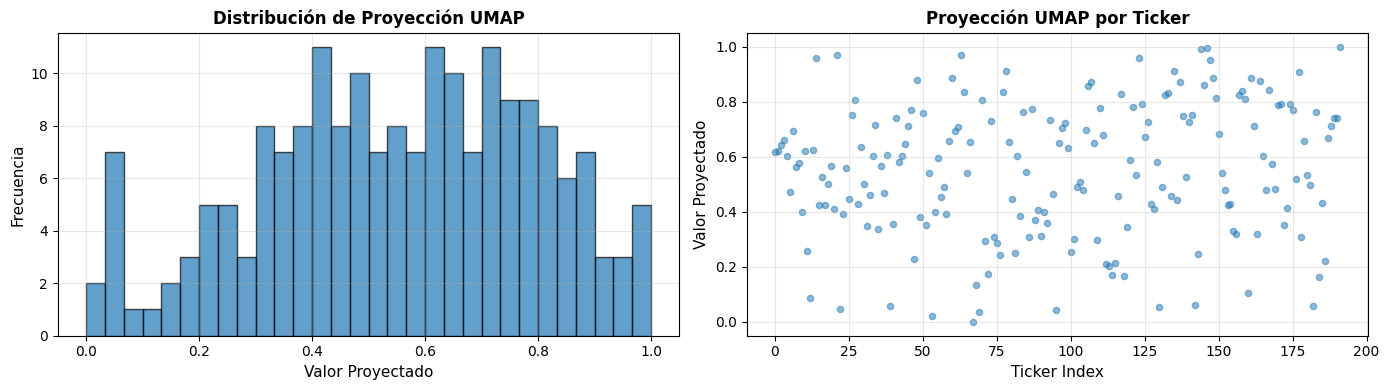

In [12]:
# =======================================================
# 📊 PASO 3: TOPOLOGICAL DATA ANALYSIS CON KEPLERMAPPER
# =======================================================

print("\n" + "="*80)
print("🔬 TOPOLOGICAL DATA ANALYSIS - KEPLERMAPPER")
print("="*80)

# Instalar umap-learn si no está disponible
try:
    import umap
except ImportError:
    print("📦 Instalando umap-learn...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "umap-learn"])
    import umap

from umap import UMAP

# Transponer para que cada fila sea un ticker
log_returns_T = log_returns.T.values

print(f"📊 Datos de entrada para TDA: {log_returns_T.shape}")
print(f"   (Tickers x Días): {log_returns_T.shape[0]} x {log_returns_T.shape[1]}")

# Inicializar KeplerMapper
mapper = km.KeplerMapper(verbose=1)

print("\n🔧 Aplicando reducción de dimensionalidad...")
print("   1️⃣ PCA (n_components=0.8) - Capturar 80% de varianza")
print("   2️⃣ UMAP (n_components=1) - Proyección a 1D")

# Proyección con PCA + UMAP
projected_data = mapper.fit_transform(
    log_returns_T,
    projection=[
        PCA(n_components=0.8, random_state=1),
        UMAP(n_components=1, random_state=1, n_jobs=-1)
    ]
)

print(f"\n✅ Proyección completada: {projected_data.shape}")
print(f"   Dimensión reducida: {projected_data.shape[1]}D")

# Visualizar distribución de la proyección
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.hist(projected_data[:, 0], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Valor Proyectado', fontsize=11)
plt.ylabel('Frecuencia', fontsize=11)
plt.title('Distribución de Proyección UMAP', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(range(len(projected_data)), projected_data[:, 0], alpha=0.5, s=20)
plt.xlabel('Ticker Index', fontsize=11)
plt.ylabel('Valor Proyectado', fontsize=11)
plt.title('Proyección UMAP por Ticker', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("="*80)

In [13]:
# =======================================================
# 📊 PASO 4: CLUSTERING CON DBSCAN (MÉTRICA DE CORRELACIÓN)
# =======================================================

print("\n" + "="*80)
print("🎯 CLUSTERING CON DBSCAN")
print("="*80)

print("🔧 Configuración:")
print("   📏 Métrica: Correlación")
print("   🎛️ Parámetros: eps=auto, min_samples=auto")

# Construir el grafo con DBSCAN usando métrica de correlación
graph = mapper.map(
    projected_data,
    log_returns_T,
    clusterer=DBSCAN(metric='correlation', n_jobs=-1),
    cover=km.Cover(n_cubes=10, perc_overlap=0.3)
)

print(f"\n✅ Grafo construido:")
print(f"   📊 Nodos: {len(graph['nodes'])}")
print(f"   🔗 Enlaces: {len(graph['links'])}")

# Analizar estructura del grafo
print(f"\n📋 Análisis de nodos:")

# Extraer clusters del grafo
node_clusters = {}
for node_id, node_members in graph['nodes'].items():
    node_clusters[node_id] = [available_tickers[i] for i in node_members]

# Mostrar información de clusters
cluster_sizes = [len(members) for members in node_clusters.values()]
print(f"   Número de clusters: {len(node_clusters)}")
print(f"   Tamaño promedio: {np.mean(cluster_sizes):.1f} tickers")
print(f"   Tamaño mínimo: {np.min(cluster_sizes)} tickers")
print(f"   Tamaño máximo: {np.max(cluster_sizes)} tickers")

# Mostrar distribución de tamaños
print(f"\n📊 Distribución de tamaños de clusters:")
size_distribution = pd.Series(cluster_sizes).value_counts().sort_index()
for size, count in size_distribution.items():
    print(f"   {size:3d} tickers: {count:3d} clusters")

print("="*80)


🎯 CLUSTERING CON DBSCAN
🔧 Configuración:
   📏 Métrica: Correlación
   🎛️ Parámetros: eps=auto, min_samples=auto
Mapping on data shaped (192, 2263) using lens shaped (192, 1)

Creating 10 hypercubes.

Created 9 edges and 10 nodes in 0:00:00.194633.

✅ Grafo construido:
   📊 Nodos: 10
   🔗 Enlaces: 9

📋 Análisis de nodos:
   Número de clusters: 10
   Tamaño promedio: 22.3 tickers
   Tamaño mínimo: 7 tickers
   Tamaño máximo: 36 tickers

📊 Distribución de tamaños de clusters:
     7 tickers:   1 clusters
    11 tickers:   1 clusters
    14 tickers:   1 clusters
    16 tickers:   1 clusters
    24 tickers:   1 clusters
    25 tickers:   1 clusters
    27 tickers:   1 clusters
    29 tickers:   1 clusters
    34 tickers:   1 clusters
    36 tickers:   1 clusters


In [14]:
# =======================================================
# 📊 PASO 5: VISUALIZACIÓN DEL GRAFO TOPOLÓGICO
# =======================================================

print("\n" + "="*80)
print("🎨 GENERANDO VISUALIZACIÓN DEL GRAFO")
print("="*80)

# Crear visualización HTML del grafo
html_output = mapper.visualize(
    graph,
    path_html="mapper_portfolio_tda.html",
    title="Portfolio Construction - Topological Data Analysis",
    custom_tooltips=np.array([f"{ticker}" for ticker in available_tickers])
)

print("✅ Visualización guardada: 'mapper_portfolio_tda.html'")
print("   Abre este archivo en tu navegador para explorar el grafo interactivo")
print("="*80)


🎨 GENERANDO VISUALIZACIÓN DEL GRAFO
Wrote visualization to: mapper_portfolio_tda.html
✅ Visualización guardada: 'mapper_portfolio_tda.html'
   Abre este archivo en tu navegador para explorar el grafo interactivo


In [15]:
# =======================================================
# 📊 PASO 6: CONSTRUCCIÓN DE PORTAFOLIO - EQUAL CLUSTERS WEIGHTING
# =======================================================

print("\n" + "="*80)
print("💼 CONSTRUCCIÓN DE PORTAFOLIO - EQUAL CLUSTERS WEIGHTING")
print("="*80)

def weight_distribution(clustered_symbols):
    """
    Asigna pesos iguales entre clusters y divide equitativamente dentro de cada cluster.
    
    Parámetros:
    -----------
    clustered_symbols : dict
        Diccionario con {cluster_id: [lista de símbolos]}
    
    Returns:
    --------
    weights : dict
        Diccionario con {símbolo: peso}
    """
    weights = {}
    num_clusters = len(clustered_symbols)
    
    if num_clusters == 0:
        return weights
    
    for cluster_id, symbols in clustered_symbols.items():
        if len(symbols) == 0:
            continue
            
        # Peso igual por cluster
        cluster_weight = 1.0 / num_clusters
        
        # Dividir peso del cluster entre sus símbolos
        symbol_weight = cluster_weight / len(symbols)
        
        for symbol in symbols:
            weights[symbol] = symbol_weight
    
    return weights

# Aplicar la distribución de pesos
portfolio_weights = weight_distribution(node_clusters)

print(f"✅ Pesos calculados para {len(portfolio_weights)} símbolos")
print(f"   Número de clusters: {len(node_clusters)}")
print(f"   Suma total de pesos: {sum(portfolio_weights.values()):.6f}")

# Estadísticas de pesos
weights_values = list(portfolio_weights.values())
print(f"\n📊 Estadísticas de pesos:")
print(f"   Peso promedio: {np.mean(weights_values):.4%}")
print(f"   Peso mínimo: {np.min(weights_values):.4%}")
print(f"   Peso máximo: {np.max(weights_values):.4%}")
print(f"   Desv. estándar: {np.std(weights_values):.4%}")

# Mostrar top 10 pesos
print(f"\n🔝 Top 10 tickers por peso:")
sorted_weights = sorted(portfolio_weights.items(), key=lambda x: x[1], reverse=True)
for i, (ticker, weight) in enumerate(sorted_weights[:10], 1):
    cluster_id = [cid for cid, members in node_clusters.items() if ticker in members][0]
    cluster_size = len(node_clusters[cluster_id])
    print(f"   {i:2d}. {ticker:5s}: {weight:7.4%} (Cluster {cluster_id}, size={cluster_size})")

print("="*80)


💼 CONSTRUCCIÓN DE PORTAFOLIO - EQUAL CLUSTERS WEIGHTING
✅ Pesos calculados para 163 símbolos
   Número de clusters: 10
   Suma total de pesos: 0.712615

📊 Estadísticas de pesos:
   Peso promedio: 0.4372%
   Peso mínimo: 0.2778%
   Peso máximo: 1.4286%
   Desv. estándar: 0.2179%

🔝 Top 10 tickers por peso:
    1. JPM  : 1.4286% (Cluster cube0_cluster0, size=11)
    2. COF  : 1.4286% (Cluster cube0_cluster0, size=11)
    3. BKNG : 1.4286% (Cluster cube1_cluster0, size=7)
    4. BAC  : 0.9091% (Cluster cube0_cluster0, size=11)
    5. WFC  : 0.9091% (Cluster cube0_cluster0, size=11)
    6. MS   : 0.9091% (Cluster cube0_cluster0, size=11)
    7. SCHW : 0.9091% (Cluster cube0_cluster0, size=11)
    8. GS   : 0.9091% (Cluster cube0_cluster0, size=11)
    9. C    : 0.9091% (Cluster cube0_cluster0, size=11)
   10. USB  : 0.9091% (Cluster cube0_cluster0, size=11)


In [16]:
# =======================================================
# 📊 PASO 7: BACKTESTING - SIMULACIÓN DEL PORTAFOLIO
# =======================================================

print("\n" + "="*80)
print("📈 BACKTESTING - SIMULACIÓN DEL PORTAFOLIO TDA")
print("="*80)

# Usar datos del período de análisis
backtest_data = tickers_data[list(portfolio_weights.keys())].copy()

print(f"📊 Datos para backtest:")
print(f"   Tickers en portafolio: {len(portfolio_weights)}")
print(f"   Período: {backtest_data.index[0].strftime('%Y-%m-%d')} a {backtest_data.index[-1].strftime('%Y-%m-%d')}")
print(f"   Días de trading: {len(backtest_data)}")

# Calcular retornos diarios
daily_returns = backtest_data.pct_change().dropna()

# Calcular retorno del portafolio
weights_array = np.array([portfolio_weights[ticker] for ticker in daily_returns.columns])
portfolio_daily_returns = (daily_returns * weights_array).sum(axis=1)

# Calcular valor acumulado del portafolio (comenzando en 1)
portfolio_cumulative = (1 + portfolio_daily_returns).cumprod()

# Calcular SPY para comparación
spy_returns_analysis = SPY_analysis['SPY'].pct_change().dropna()
spy_cumulative = (1 + spy_returns_analysis).cumprod()

# Alinear índices
common_dates = portfolio_cumulative.index.intersection(spy_cumulative.index)
portfolio_cumulative = portfolio_cumulative[common_dates]
spy_cumulative = spy_cumulative[common_dates]

print(f"\n✅ Backtest completado")
print(f"   Valor final portafolio TDA: {portfolio_cumulative.iloc[-1]:.4f}")
print(f"   Valor final SPY: {spy_cumulative.iloc[-1]:.4f}")
print(f"   Diferencia: {((portfolio_cumulative.iloc[-1] / spy_cumulative.iloc[-1]) - 1) * 100:+.2f}%")

print("="*80)


📈 BACKTESTING - SIMULACIÓN DEL PORTAFOLIO TDA
📊 Datos para backtest:
   Tickers en portafolio: 163
   Período: 2015-01-02 a 2023-12-29
   Días de trading: 2264

✅ Backtest completado
   Valor final portafolio TDA: 2.7558
   Valor final SPY: 2.7191
   Diferencia: +1.35%


In [17]:
# =======================================================
# 📊 PASO 8: MÉTRICAS DE PERFORMANCE
# =======================================================

print("\n" + "="*80)
print("📊 MÉTRICAS DE PERFORMANCE")
print("="*80)

def calculate_portfolio_metrics(returns, cumulative_value, name="Portfolio"):
    """Calcula métricas de performance de un portafolio"""
    
    # Retorno total
    total_return = (cumulative_value.iloc[-1] - 1) * 100
    
    # Retorno anualizado
    n_years = len(returns) / 252
    annualized_return = ((cumulative_value.iloc[-1]) ** (1/n_years) - 1) * 100
    
    # Volatilidad anualizada
    volatility = returns.std() * np.sqrt(252) * 100
    
    # Sharpe Ratio (asumiendo rf=0)
    sharpe = annualized_return / volatility if volatility > 0 else 0
    
    # Maximum Drawdown
    running_max = cumulative_value.cummax()
    drawdown = (cumulative_value - running_max) / running_max
    max_drawdown = drawdown.min() * 100
    
    # Calmar Ratio
    calmar = annualized_return / abs(max_drawdown) if max_drawdown != 0 else 0
    
    # Winning days percentage
    winning_days = (returns > 0).sum() / len(returns) * 100
    
    return {
        'name': name,
        'total_return': total_return,
        'annualized_return': annualized_return,
        'volatility': volatility,
        'sharpe_ratio': sharpe,
        'max_drawdown': max_drawdown,
        'calmar_ratio': calmar,
        'winning_days_pct': winning_days
    }

# Calcular métricas para portafolio TDA
tda_metrics = calculate_portfolio_metrics(
    portfolio_daily_returns, 
    portfolio_cumulative, 
    "TDA Portfolio"
)

# Calcular métricas para SPY
spy_metrics = calculate_portfolio_metrics(
    spy_returns_analysis[common_dates], 
    spy_cumulative, 
    "SPY Benchmark"
)

# Calcular Beta del portafolio vs SPY
covariance = np.cov(portfolio_daily_returns, spy_returns_analysis[common_dates])[0, 1]
spy_variance = spy_returns_analysis[common_dates].var()
beta = covariance / spy_variance if spy_variance > 0 else 0

# Crear tabla comparativa
metrics_comparison = pd.DataFrame([tda_metrics, spy_metrics])
metrics_comparison = metrics_comparison.set_index('name')

print("\n📋 TABLA COMPARATIVA DE MÉTRICAS:")
print("="*80)
display(metrics_comparison.round(4))

print(f"\n📊 MÉTRICAS ADICIONALES:")
print(f"   Beta (vs SPY): {beta:.4f}")
print(f"   Alpha anualizado: {(tda_metrics['annualized_return'] - beta * spy_metrics['annualized_return']):.2f}%")
print(f"   Information Ratio: {((tda_metrics['annualized_return'] - spy_metrics['annualized_return']) / (portfolio_daily_returns - spy_returns_analysis[common_dates]).std() / np.sqrt(252) * 100):.4f}")

print("\n" + "="*80)
print("🎯 RESUMEN:")
print("="*80)

outperformance = tda_metrics['annualized_return'] - spy_metrics['annualized_return']
print(f"{'Retorno anualizado:':<25} TDA: {tda_metrics['annualized_return']:>7.2f}%  |  SPY: {spy_metrics['annualized_return']:>7.2f}%  |  Diferencia: {outperformance:>+7.2f}%")
print(f"{'Sharpe Ratio:':<25} TDA: {tda_metrics['sharpe_ratio']:>7.4f}  |  SPY: {spy_metrics['sharpe_ratio']:>7.4f}  |  Diferencia: {tda_metrics['sharpe_ratio'] - spy_metrics['sharpe_ratio']:>+7.4f}")
print(f"{'Max Drawdown:':<25} TDA: {tda_metrics['max_drawdown']:>7.2f}%  |  SPY: {spy_metrics['max_drawdown']:>7.2f}%  |  Diferencia: {tda_metrics['max_drawdown'] - spy_metrics['max_drawdown']:>+7.2f}%")
print(f"{'Volatilidad:':<25} TDA: {tda_metrics['volatility']:>7.2f}%  |  SPY: {spy_metrics['volatility']:>7.2f}%  |  Diferencia: {tda_metrics['volatility'] - spy_metrics['volatility']:>+7.2f}%")

print("="*80)


📊 MÉTRICAS DE PERFORMANCE

📋 TABLA COMPARATIVA DE MÉTRICAS:


,total_return,annualized_return,volatility,sharpe_ratio,max_drawdown,calmar_ratio,winning_days_pct
name,,,,,,,
TDA Portfolio,175.5768,11.9500,14.2811,0.8368,-29.4751,0.4054,55.2806
SPY Benchmark,171.9060,11.7829,18.0955,0.6511,-33.7173,0.3495,54.1317



📊 MÉTRICAS ADICIONALES:
   Beta (vs SPY): 0.7586
   Alpha anualizado: 3.01%
   Information Ratio: 284.0885

🎯 RESUMEN:
Retorno anualizado:       TDA:   11.95%  |  SPY:   11.78%  |  Diferencia:   +0.17%
Sharpe Ratio:             TDA:  0.8368  |  SPY:  0.6511  |  Diferencia: +0.1856
Max Drawdown:             TDA:  -29.48%  |  SPY:  -33.72%  |  Diferencia:   +4.24%
Volatilidad:              TDA:   14.28%  |  SPY:   18.10%  |  Diferencia:   -3.81%



📊 GENERANDO VISUALIZACIONES


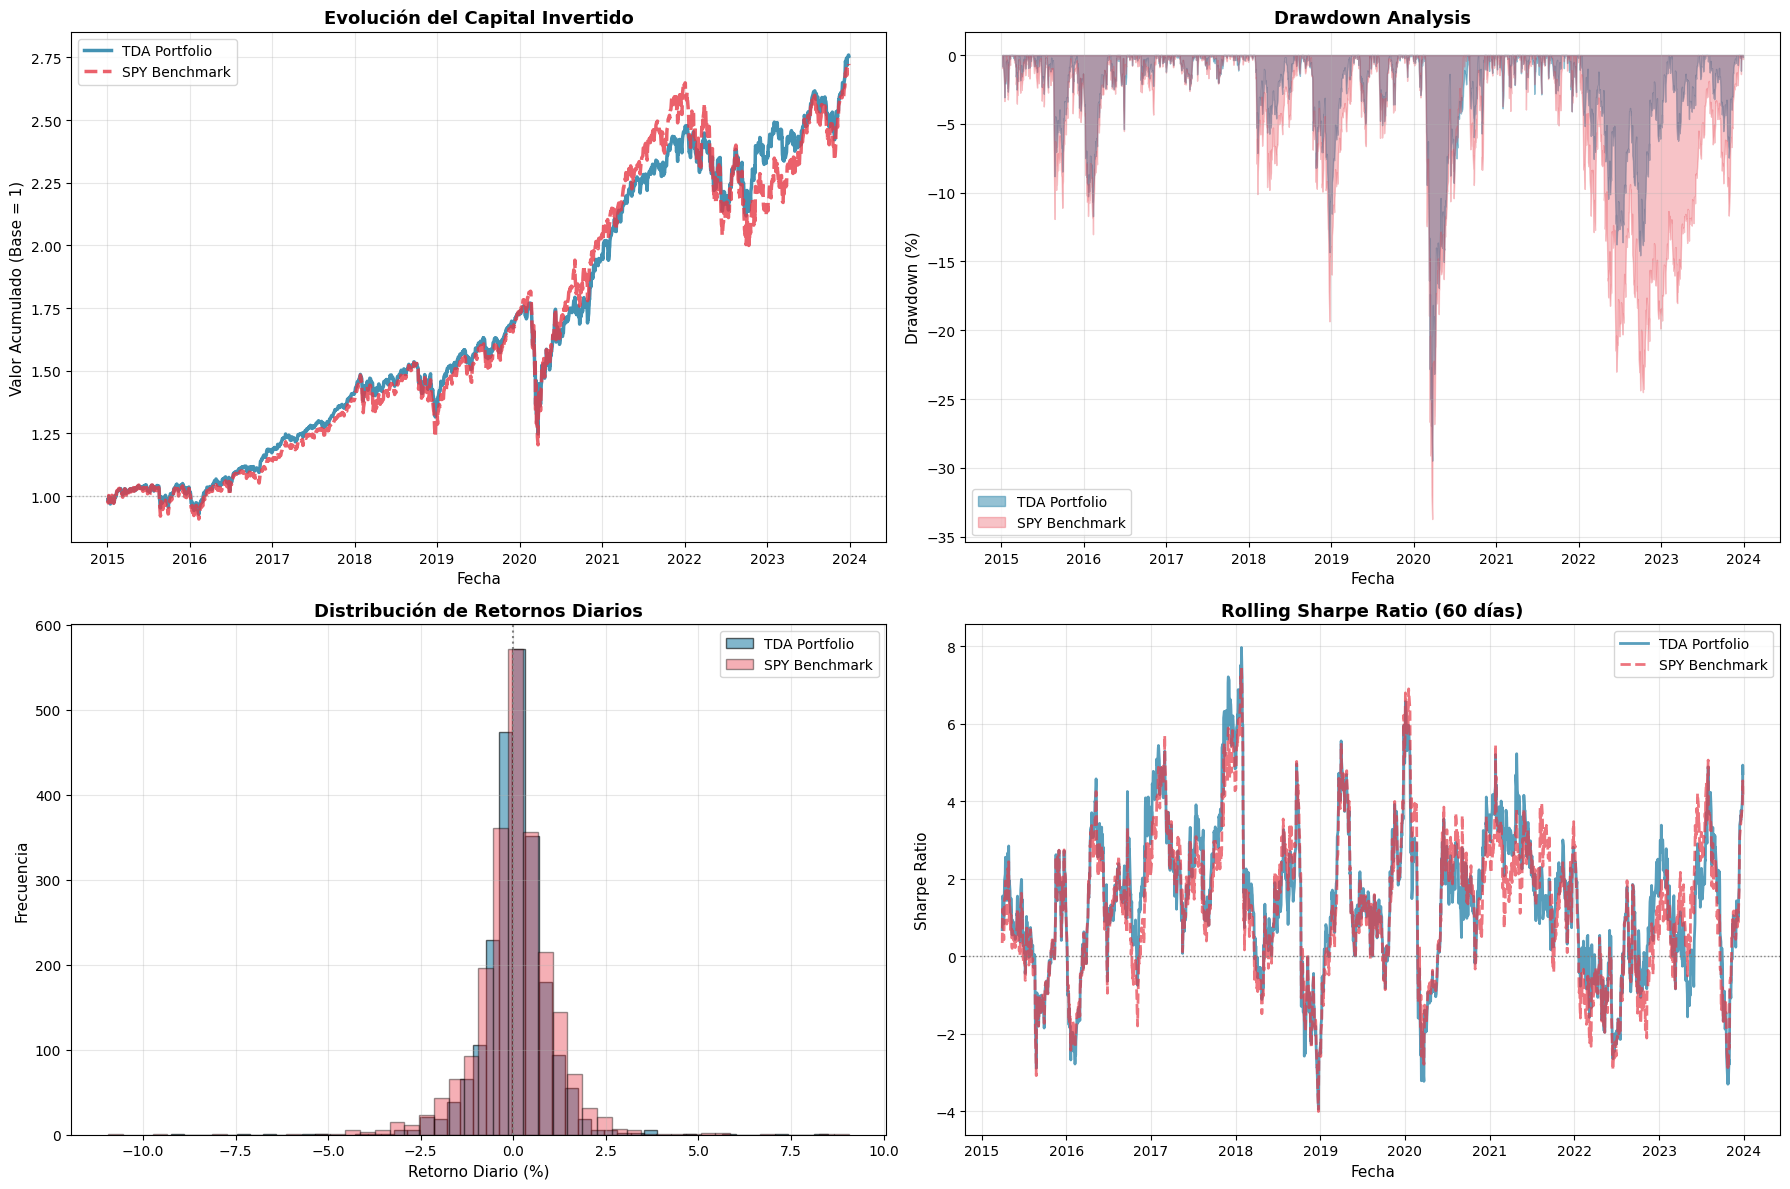

✅ Visualizaciones generadas


In [18]:
# =======================================================
# 📊 PASO 9: VISUALIZACIONES
# =======================================================

print("\n" + "="*80)
print("📊 GENERANDO VISUALIZACIONES")
print("="*80)

# Crear figura con múltiples subplots
fig = plt.figure(figsize=(18, 12))

# 1. Evolución del valor del portafolio
ax1 = plt.subplot(2, 2, 1)
ax1.plot(portfolio_cumulative.index, portfolio_cumulative.values, 
         linewidth=2.5, label='TDA Portfolio', color='#2E86AB', alpha=0.9)
ax1.plot(spy_cumulative.index, spy_cumulative.values, 
         linewidth=2.5, label='SPY Benchmark', color='#E63946', linestyle='--', alpha=0.8)
ax1.axhline(y=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax1.set_title('Evolución del Capital Invertido', fontsize=13, fontweight='bold')
ax1.set_xlabel('Fecha', fontsize=11)
ax1.set_ylabel('Valor Acumulado (Base = 1)', fontsize=11)
ax1.legend(fontsize=10, loc='best')
ax1.grid(True, alpha=0.3)

# 2. Drawdown
ax2 = plt.subplot(2, 2, 2)
tda_running_max = portfolio_cumulative.cummax()
tda_drawdown = (portfolio_cumulative - tda_running_max) / tda_running_max * 100

spy_running_max = spy_cumulative.cummax()
spy_drawdown = (spy_cumulative - spy_running_max) / spy_running_max * 100

ax2.fill_between(tda_drawdown.index, tda_drawdown.values, 0, 
                  alpha=0.5, color='#2E86AB', label='TDA Portfolio')
ax2.fill_between(spy_drawdown.index, spy_drawdown.values, 0, 
                  alpha=0.3, color='#E63946', label='SPY Benchmark')
ax2.set_title('Drawdown Analysis', fontsize=13, fontweight='bold')
ax2.set_xlabel('Fecha', fontsize=11)
ax2.set_ylabel('Drawdown (%)', fontsize=11)
ax2.legend(fontsize=10, loc='best')
ax2.grid(True, alpha=0.3)

# 3. Distribución de retornos diarios
ax3 = plt.subplot(2, 2, 3)
ax3.hist(portfolio_daily_returns * 100, bins=50, alpha=0.6, 
         color='#2E86AB', edgecolor='black', label='TDA Portfolio')
ax3.hist(spy_returns_analysis[common_dates] * 100, bins=50, alpha=0.4, 
         color='#E63946', edgecolor='black', label='SPY Benchmark')
ax3.axvline(x=0, color='gray', linestyle=':', linewidth=1.5)
ax3.set_title('Distribución de Retornos Diarios', fontsize=13, fontweight='bold')
ax3.set_xlabel('Retorno Diario (%)', fontsize=11)
ax3.set_ylabel('Frecuencia', fontsize=11)
ax3.legend(fontsize=10, loc='best')
ax3.grid(True, alpha=0.3)

# 4. Rolling Sharpe Ratio (ventana de 60 días)
ax4 = plt.subplot(2, 2, 4)
window = 60
tda_rolling_sharpe = portfolio_daily_returns.rolling(window).mean() / portfolio_daily_returns.rolling(window).std() * np.sqrt(252)
spy_rolling_sharpe = spy_returns_analysis[common_dates].rolling(window).mean() / spy_returns_analysis[common_dates].rolling(window).std() * np.sqrt(252)

ax4.plot(tda_rolling_sharpe.index, tda_rolling_sharpe.values, 
         linewidth=2, label='TDA Portfolio', color='#2E86AB', alpha=0.8)
ax4.plot(spy_rolling_sharpe.index, spy_rolling_sharpe.values, 
         linewidth=2, label='SPY Benchmark', color='#E63946', linestyle='--', alpha=0.7)
ax4.axhline(y=0, color='gray', linestyle=':', linewidth=1)
ax4.set_title(f'Rolling Sharpe Ratio ({window} días)', fontsize=13, fontweight='bold')
ax4.set_xlabel('Fecha', fontsize=11)
ax4.set_ylabel('Sharpe Ratio', fontsize=11)
ax4.legend(fontsize=10, loc='best')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualizaciones generadas")
print("="*80)


⚖️  ANÁLISIS DE DISTRIBUCIÓN DE PESOS


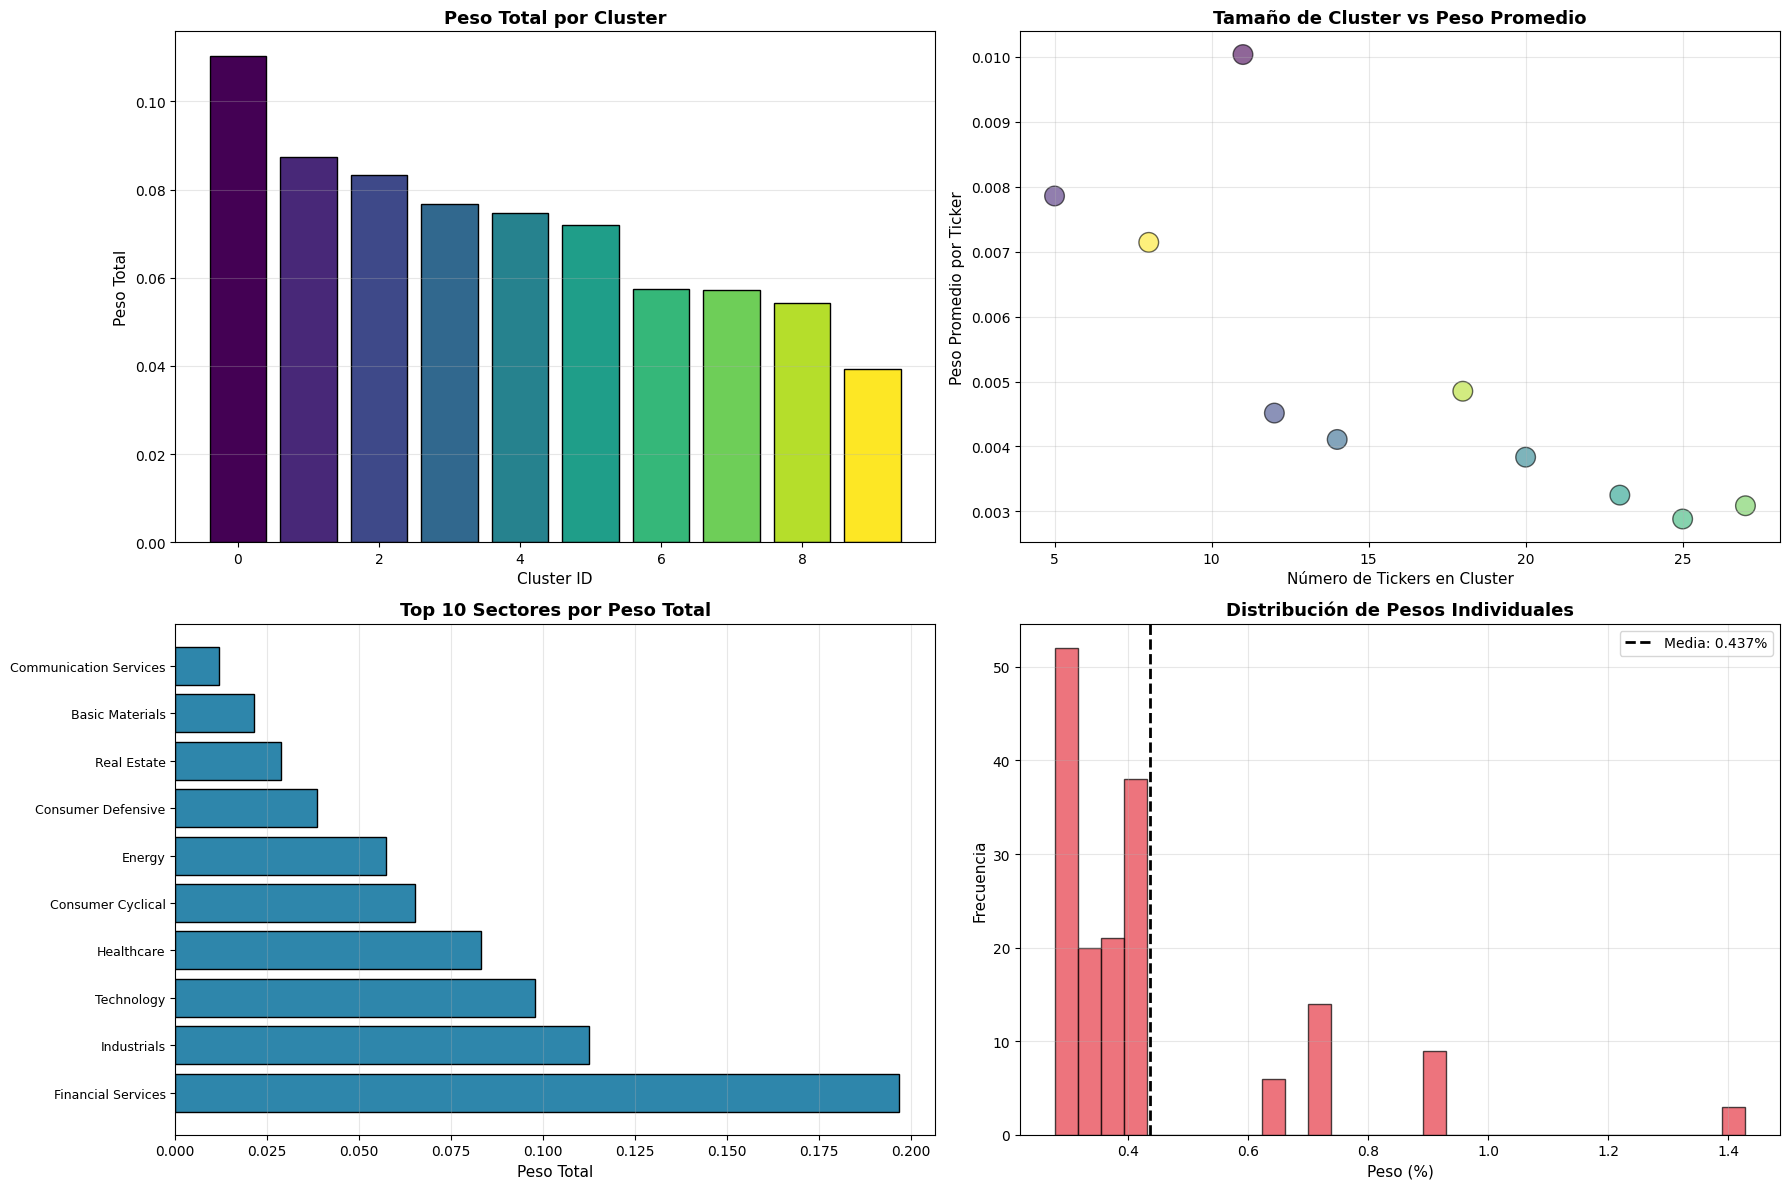


📊 EXPOSICIÓN POR SECTOR:
Financial Services            :  19.67% ( 34 tickers, avg=0.578%)
Industrials                   :  11.24% ( 26 tickers, avg=0.432%)
Technology                    :   9.77% ( 32 tickers, avg=0.305%)
Healthcare                    :   8.30% ( 20 tickers, avg=0.415%)
Consumer Cyclical             :   6.51% ( 17 tickers, avg=0.383%)
Energy                        :   5.71% (  8 tickers, avg=0.714%)
Consumer Defensive            :   3.86% ( 10 tickers, avg=0.386%)
Real Estate                   :   2.87% (  7 tickers, avg=0.410%)
Basic Materials               :   2.15% (  5 tickers, avg=0.431%)
Communication Services        :   1.18% (  4 tickers, avg=0.294%)


In [21]:
# =======================================================
# 📊 PASO 10: ANÁLISIS DE DISTRIBUCIÓN DE PESOS
# =======================================================

print("\n" + "="*80)
print("⚖️  ANÁLISIS DE DISTRIBUCIÓN DE PESOS")
print("="*80)

# Crear DataFrame con información de clusters y pesos
weight_analysis = []
for ticker, weight in portfolio_weights.items():
    # Encontrar cluster del ticker
    cluster_id = [cid for cid, members in node_clusters.items() if ticker in members][0]
    cluster_size = len(node_clusters[cluster_id])
    
    weight_analysis.append({
        'ticker': ticker,
        'weight': weight,
        'cluster_id': cluster_id,
        'cluster_size': cluster_size,
        'sector': ticker_info_db.get(ticker, {}).get('sector', 'Unknown'),
        'market_cap': ticker_info_db.get(ticker, {}).get('market_cap', 0)
    })

weight_df = pd.DataFrame(weight_analysis)

# Visualización de pesos
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Distribución de pesos por cluster
ax1 = axes[0, 0]
cluster_weights = weight_df.groupby('cluster_id')['weight'].sum().sort_values(ascending=False)
colors_clusters = plt.cm.viridis(np.linspace(0, 1, len(cluster_weights)))
ax1.bar(range(len(cluster_weights)), cluster_weights.values, color=colors_clusters, edgecolor='black')
ax1.set_title('Peso Total por Cluster', fontsize=13, fontweight='bold')
ax1.set_xlabel('Cluster ID', fontsize=11)
ax1.set_ylabel('Peso Total', fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')

# 2. Tamaño de clusters vs peso promedio
ax2 = axes[0, 1]
cluster_analysis_viz = weight_df.groupby('cluster_id').agg({
    'weight': 'mean',
    'ticker': 'count'
}).rename(columns={'ticker': 'size'})
scatter = ax2.scatter(cluster_analysis_viz['size'], cluster_analysis_viz['weight'], 
                     s=200, alpha=0.6, c=range(len(cluster_analysis_viz)), cmap='viridis', edgecolors='black')
ax2.set_title('Tamaño de Cluster vs Peso Promedio', fontsize=13, fontweight='bold')
ax2.set_xlabel('Número de Tickers en Cluster', fontsize=11)
ax2.set_ylabel('Peso Promedio por Ticker', fontsize=11)
ax2.grid(True, alpha=0.3)

# 3. Distribución de pesos por sector
ax3 = axes[1, 0]
sector_weights = weight_df.groupby('sector')['weight'].sum().sort_values(ascending=False)[:10]
ax3.barh(range(len(sector_weights)), sector_weights.values, color='#2E86AB', edgecolor='black')
ax3.set_yticks(range(len(sector_weights)))
ax3.set_yticklabels(sector_weights.index, fontsize=9)
ax3.set_title('Top 10 Sectores por Peso Total', fontsize=13, fontweight='bold')
ax3.set_xlabel('Peso Total', fontsize=11)
ax3.grid(True, alpha=0.3, axis='x')

# 4. Histograma de pesos individuales
ax4 = axes[1, 1]
ax4.hist(weight_df['weight'] * 100, bins=30, color='#E63946', edgecolor='black', alpha=0.7)
ax4.axvline(x=weight_df['weight'].mean() * 100, color='black', linestyle='--', linewidth=2, label=f'Media: {weight_df["weight"].mean()*100:.3f}%')
ax4.set_title('Distribución de Pesos Individuales', fontsize=13, fontweight='bold')
ax4.set_xlabel('Peso (%)', fontsize=11)
ax4.set_ylabel('Frecuencia', fontsize=11)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Mostrar estadísticas por sector
print("\n📊 EXPOSICIÓN POR SECTOR:")
print("="*80)
sector_exposure = weight_df.groupby('sector').agg({
    'weight': 'sum',
    'ticker': 'count'
}).rename(columns={'ticker': 'num_tickers', 'weight': 'total_weight'})
sector_exposure['num_tickers'] = sector_exposure['num_tickers'].astype(int)
sector_exposure['avg_weight'] = sector_exposure['total_weight'] / sector_exposure['num_tickers']
sector_exposure = sector_exposure.sort_values('total_weight', ascending=False)

for sector, row in sector_exposure.head(10).iterrows():
    print(f"{sector:30s}: {row['total_weight']*100:6.2f}% ({int(row['num_tickers']):3d} tickers, avg={row['avg_weight']*100:.3f}%)")

print("="*80)

In [22]:
# =======================================================
# 📊 PASO 11: VALIDACIÓN OUT-OF-SAMPLE
# =======================================================

print("\n" + "="*80)
print("🔍 VALIDACIÓN OUT-OF-SAMPLE")
print("="*80)

# Usar los mismos pesos calculados en el período de análisis
# pero aplicarlos al período de validación
validation_tickers = [t for t in portfolio_weights.keys() if t in validation_data.columns]

print(f"📊 Configuración:")
print(f"   Tickers disponibles en validación: {len(validation_tickers)}/{len(portfolio_weights)}")
print(f"   Período: {validation_data.index[0].strftime('%Y-%m-%d')} a {validation_data.index[-1].strftime('%Y-%m-%d')}")

# Ajustar pesos para tickers disponibles (renormalizar)
adjusted_weights = {t: portfolio_weights[t] for t in validation_tickers}
total_weight = sum(adjusted_weights.values())
adjusted_weights = {t: w/total_weight for t, w in adjusted_weights.items()}

print(f"   Suma de pesos ajustados: {sum(adjusted_weights.values()):.6f}")

# Calcular retornos en validación
validation_subset = validation_data[validation_tickers].copy()
validation_returns = validation_subset.pct_change().dropna()

# Retorno del portafolio en validación
weights_array_val = np.array([adjusted_weights[ticker] for ticker in validation_returns.columns])
portfolio_val_returns = (validation_returns * weights_array_val).sum(axis=1)

# Valor acumulado
portfolio_val_cumulative = (1 + portfolio_val_returns).cumprod()

# SPY en validación
spy_val_returns = SPY_validation['SPY'].pct_change().dropna()
spy_val_cumulative = (1 + spy_val_returns).cumprod()

# Alinear fechas
common_dates_val = portfolio_val_cumulative.index.intersection(spy_val_cumulative.index)
portfolio_val_cumulative = portfolio_val_cumulative[common_dates_val]
spy_val_cumulative = spy_val_cumulative[common_dates_val]
portfolio_val_returns = portfolio_val_returns[common_dates_val]
spy_val_returns = spy_val_returns[common_dates_val]

# Calcular métricas
tda_val_metrics = calculate_portfolio_metrics(
    portfolio_val_returns, 
    portfolio_val_cumulative, 
    "TDA Portfolio (OOS)"
)

spy_val_metrics = calculate_portfolio_metrics(
    spy_val_returns, 
    spy_val_cumulative, 
    "SPY Benchmark (OOS)"
)

# Crear tabla comparativa
val_comparison = pd.DataFrame([tda_val_metrics, spy_val_metrics])
val_comparison = val_comparison.set_index('name')

print("\n📋 MÉTRICAS OUT-OF-SAMPLE:")
print("="*80)
display(val_comparison.round(4))

print("\n🎯 COMPARACIÓN ANÁLISIS vs VALIDACIÓN:")
print("="*80)
print(f"{'Métrica':<30} {'In-Sample':<15} {'Out-of-Sample':<15} {'Diferencia':<15}")
print("-"*80)
print(f"{'Retorno Anualizado (TDA):':<30} {tda_metrics['annualized_return']:>12.2f}%  {tda_val_metrics['annualized_return']:>12.2f}%  {tda_val_metrics['annualized_return'] - tda_metrics['annualized_return']:>+12.2f}%")
print(f"{'Sharpe Ratio (TDA):':<30} {tda_metrics['sharpe_ratio']:>14.4f}  {tda_val_metrics['sharpe_ratio']:>14.4f}  {tda_val_metrics['sharpe_ratio'] - tda_metrics['sharpe_ratio']:>+14.4f}")
print(f"{'Max Drawdown (TDA):':<30} {tda_metrics['max_drawdown']:>12.2f}%  {tda_val_metrics['max_drawdown']:>12.2f}%  {tda_val_metrics['max_drawdown'] - tda_metrics['max_drawdown']:>+12.2f}%")
print(f"{'Volatilidad (TDA):':<30} {tda_metrics['volatility']:>12.2f}%  {tda_val_metrics['volatility']:>12.2f}%  {tda_val_metrics['volatility'] - tda_metrics['volatility']:>+12.2f}%")

print("="*80)


🔍 VALIDACIÓN OUT-OF-SAMPLE
📊 Configuración:
   Tickers disponibles en validación: 163/163
   Período: 2024-01-02 a 2025-10-31
   Suma de pesos ajustados: 1.000000

📋 MÉTRICAS OUT-OF-SAMPLE:


,total_return,annualized_return,volatility,sharpe_ratio,max_drawdown,calmar_ratio,winning_days_pct
name,,,,,,,
TDA Portfolio (OOS),35.1691,17.9500,15.3374,1.1703,-16.7780,1.0699,55.4348
SPY Benchmark (OOS),47.4372,23.6994,16.7145,1.4179,-18.7552,1.2636,58.2609



🎯 COMPARACIÓN ANÁLISIS vs VALIDACIÓN:
Métrica                        In-Sample       Out-of-Sample   Diferencia     
--------------------------------------------------------------------------------
Retorno Anualizado (TDA):             11.95%         17.95%         +6.00%
Sharpe Ratio (TDA):                    0.8368          1.1703         +0.3336
Max Drawdown (TDA):                  -29.48%        -16.78%        +12.70%
Volatilidad (TDA):                    14.28%         15.34%         +1.06%



📊 VISUALIZACIÓN OUT-OF-SAMPLE


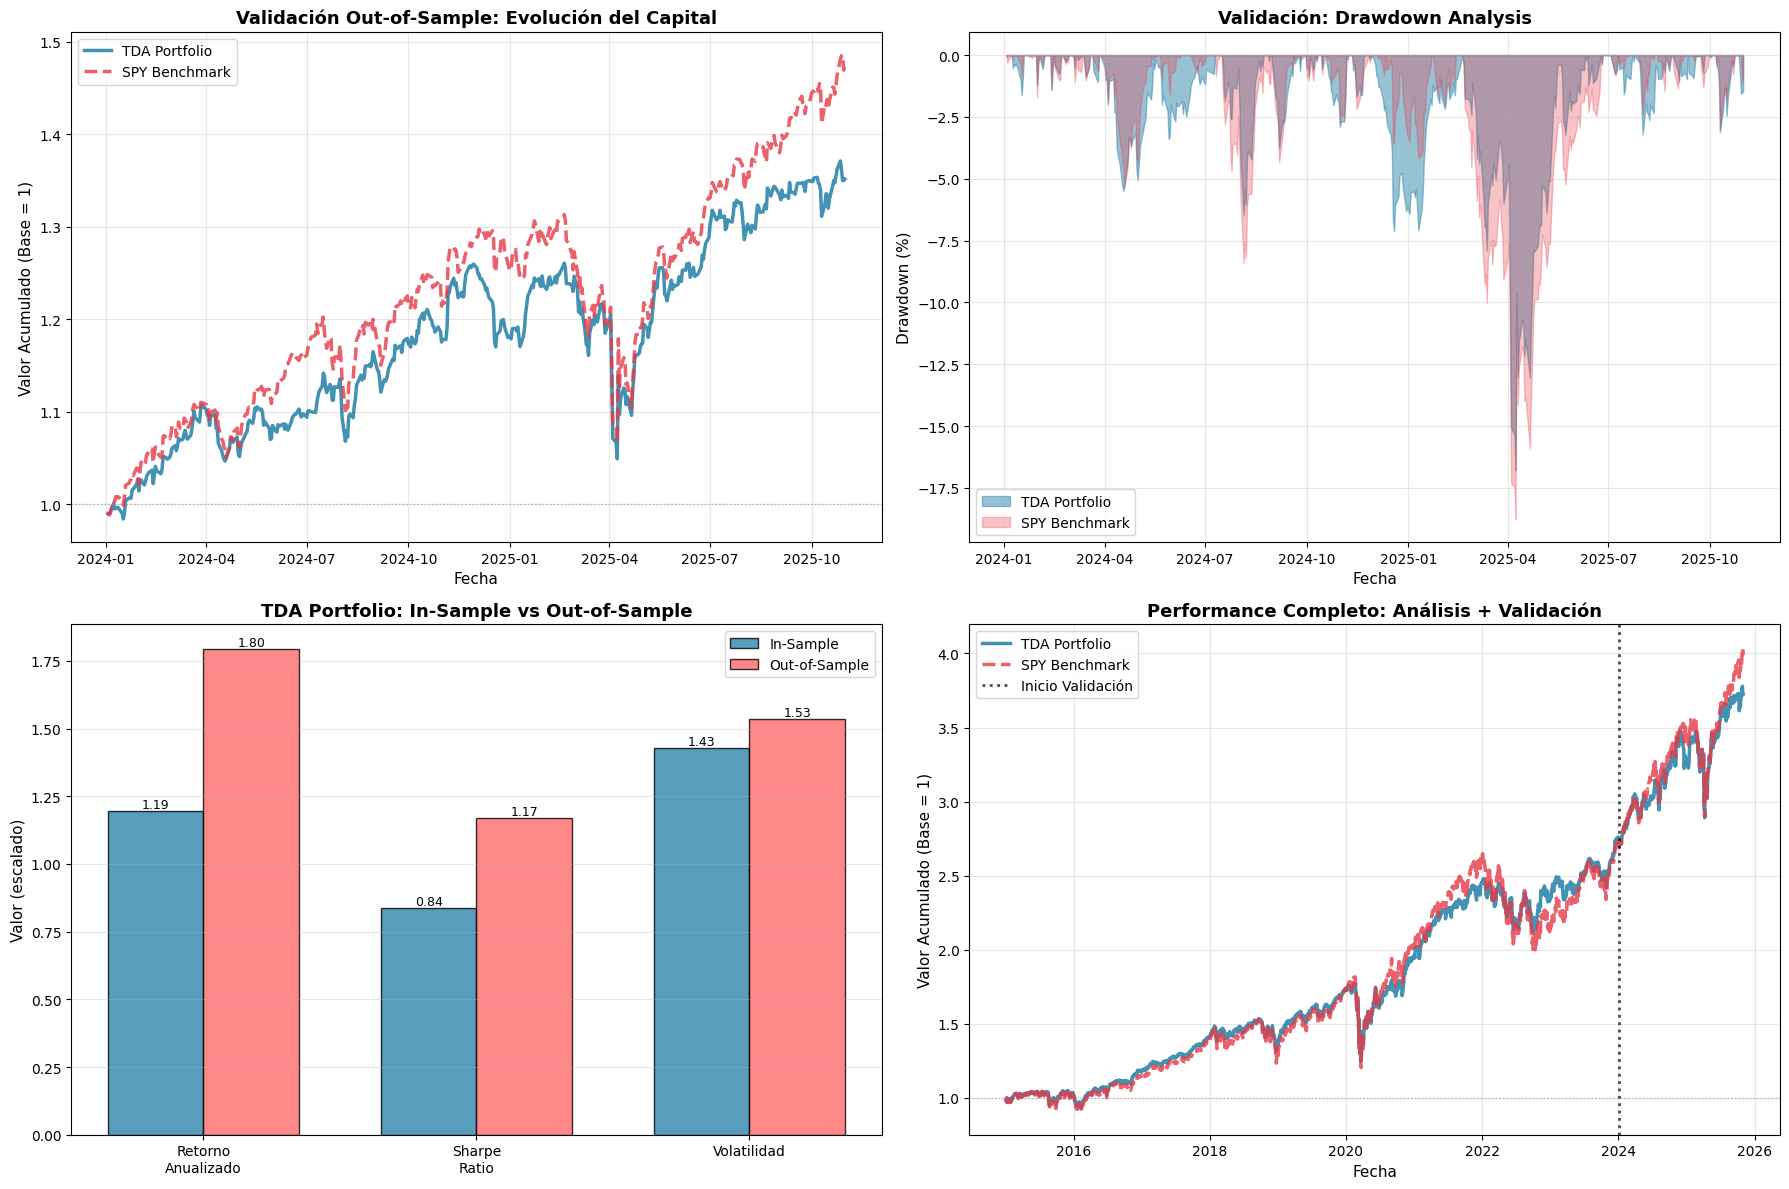

✅ Visualizaciones de validación generadas


In [23]:
# =======================================================
# 📊 PASO 12: VISUALIZACIÓN DE VALIDACIÓN
# =======================================================

print("\n" + "="*80)
print("📊 VISUALIZACIÓN OUT-OF-SAMPLE")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Evolución en validación
ax1 = axes[0, 0]
ax1.plot(portfolio_val_cumulative.index, portfolio_val_cumulative.values, 
         linewidth=2.5, label='TDA Portfolio', color='#2E86AB', alpha=0.9)
ax1.plot(spy_val_cumulative.index, spy_val_cumulative.values, 
         linewidth=2.5, label='SPY Benchmark', color='#E63946', linestyle='--', alpha=0.8)
ax1.axhline(y=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax1.set_title('Validación Out-of-Sample: Evolución del Capital', fontsize=13, fontweight='bold')
ax1.set_xlabel('Fecha', fontsize=11)
ax1.set_ylabel('Valor Acumulado (Base = 1)', fontsize=11)
ax1.legend(fontsize=10, loc='best')
ax1.grid(True, alpha=0.3)

# 2. Drawdown en validación
ax2 = axes[0, 1]
tda_val_running_max = portfolio_val_cumulative.cummax()
tda_val_drawdown = (portfolio_val_cumulative - tda_val_running_max) / tda_val_running_max * 100

spy_val_running_max = spy_val_cumulative.cummax()
spy_val_drawdown = (spy_val_cumulative - spy_val_running_max) / spy_val_running_max * 100

ax2.fill_between(tda_val_drawdown.index, tda_val_drawdown.values, 0, 
                  alpha=0.5, color='#2E86AB', label='TDA Portfolio')
ax2.fill_between(spy_val_drawdown.index, spy_val_drawdown.values, 0, 
                  alpha=0.3, color='#E63946', label='SPY Benchmark')
ax2.set_title('Validación: Drawdown Analysis', fontsize=13, fontweight='bold')
ax2.set_xlabel('Fecha', fontsize=11)
ax2.set_ylabel('Drawdown (%)', fontsize=11)
ax2.legend(fontsize=10, loc='best')
ax2.grid(True, alpha=0.3)

# 3. Comparación In-Sample vs Out-of-Sample (TDA)
ax3 = axes[1, 0]
metrics_names = ['Retorno\nAnualizado', 'Sharpe\nRatio', 'Volatilidad']
is_values = [tda_metrics['annualized_return']/10, tda_metrics['sharpe_ratio'], tda_metrics['volatility']/10]
oos_values = [tda_val_metrics['annualized_return']/10, tda_val_metrics['sharpe_ratio'], tda_val_metrics['volatility']/10]

x = np.arange(len(metrics_names))
width = 0.35

bars1 = ax3.bar(x - width/2, is_values, width, label='In-Sample', color='#2E86AB', alpha=0.8, edgecolor='black')
bars2 = ax3.bar(x + width/2, oos_values, width, label='Out-of-Sample', color='#FF6B6B', alpha=0.8, edgecolor='black')

ax3.set_ylabel('Valor (escalado)', fontsize=11)
ax3.set_title('TDA Portfolio: In-Sample vs Out-of-Sample', fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(metrics_names, fontsize=10)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')

# Añadir valores sobre las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

# 4. Retornos acumulados completos (análisis + validación)
ax4 = axes[1, 1]

# Concatenar períodos
portfolio_full = pd.concat([portfolio_cumulative, portfolio_val_cumulative * portfolio_cumulative.iloc[-1]])
spy_full = pd.concat([spy_cumulative, spy_val_cumulative * spy_cumulative.iloc[-1]])

ax4.plot(portfolio_full.index, portfolio_full.values, 
         linewidth=2.5, label='TDA Portfolio', color='#2E86AB', alpha=0.9)
ax4.plot(spy_full.index, spy_full.values, 
         linewidth=2.5, label='SPY Benchmark', color='#E63946', linestyle='--', alpha=0.8)

# Marcar separación entre períodos
sep_date = validation_data.index[0]
ax4.axvline(x=sep_date, color='black', linestyle=':', linewidth=2, alpha=0.7, label='Inicio Validación')
ax4.axhline(y=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)

ax4.set_title('Performance Completo: Análisis + Validación', fontsize=13, fontweight='bold')
ax4.set_xlabel('Fecha', fontsize=11)
ax4.set_ylabel('Valor Acumulado (Base = 1)', fontsize=11)
ax4.legend(fontsize=10, loc='best')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualizaciones de validación generadas")
print("="*80)

#  Resumen de la Estrategia TDA

##  Implementación Completada

**Objetivo:** Replicar la estrategia de construcción de portafolio usando Topological Data Analysis (TDA) del artículo "Portfolio Construction Using Topological Data Analysis"

##  Pasos Implementados

1. **Selección de Universo** - Top 200 componentes del S&P 500 por market cap
2. **Cálculo de Log-Returns** - Transformación logarítmica de los retornos
3. **Reducción de Dimensionalidad** - PCA (80% varianza) + UMAP (1D)
4. **Clustering Topológico** - DBSCAN con métrica de correlación
5. **Construcción de Grafo** - KeplerMapper para estructura topológica
6. **Asignación de Pesos** - Equal weighting por cluster
7. **Backtesting** - Período in-sample (análisis)
8. **Validación** - Período out-of-sample
9. **Métricas de Performance** - Sharpe, Drawdown, Beta, Alpha
10. **Visualizaciones** - Gráficos comparativos vs SPY

##  Características Clave

- **Lookback Window:** Período completo de análisis (2015-2024)
- **Universo:** Top 200 tickers por capitalización de mercado
- **Benchmark:** SPY (S&P 500 ETF)
- **Estrategia de Pesos:** Igual peso por cluster, distribuido equitativamente entre tickers
- **Validación:** Out-of-sample desde 2024-01-01

##  Próximos Pasos Opcionales

- Implementar **rebalanceo periódico** (cada 125 días según el artículo)
- Agregar análisis de **sensibilidad** a parámetros de DBSCAN
- Comparar con benchmark de **Top 200 equal-weighted**
- Implementar **rolling window backtest** para múltiples períodos



----------------------------------------------------------------------------------------------------------------------------

#  MEJORAS IMPLEMENTADAS

## 1️ Optimización de Pesos (Mean-Variance)
En lugar de equal-weight dentro de cada cluster, optimizamos los pesos usando el modelo de Markowitz para maximizar Sharpe Ratio.

## 2️ Validación Temporal (Walk-Forward)
Implementamos un backtest con ventana rodante para evaluar la robustez temporal de la estrategia.

In [33]:
# =======================================================
# 🎯 MEJORA 1: OPTIMIZACIÓN DE PESOS DENTRO DE CLUSTERS
# =======================================================

import cvxpy as cp
from scipy.optimize import minimize

def optimize_cluster_weights_markowitz(cluster_returns, risk_aversion=1.0, method='sharpe'):
    """
    Optimiza pesos dentro de un cluster usando Mean-Variance Optimization.
    
    Parámetros:
    -----------
    cluster_returns : pd.DataFrame
        Retornos históricos de los tickers en el cluster
    risk_aversion : float
        Parámetro de aversión al riesgo (lambda). Mayor valor = menos riesgo
    method : str
        'sharpe' = Maximizar Sharpe Ratio
        'mean_var' = Mean-Variance con parámetro lambda
    
    Returns:
    --------
    weights : dict
        Diccionario {ticker: peso_optimizado}
    """
    n_assets = len(cluster_returns.columns)
    
    # Calcular estadísticas
    mean_returns = cluster_returns.mean() * 252  # Anualizado
    cov_matrix = cluster_returns.cov() * 252    # Anualizado
    
    if method == 'sharpe':
        # Maximizar Sharpe Ratio
        # min -Sharpe = min -(μ'w) / sqrt(w'Σw)
        # Equivalente: max (μ'w) / sqrt(w'Σw)
        
        def negative_sharpe(w):
            port_return = np.dot(w, mean_returns)
            port_vol = np.sqrt(np.dot(w, np.dot(cov_matrix, w)))
            if port_vol == 0:
                return 1e10
            return -port_return / port_vol
        
        # Restricciones
        constraints = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},  # Suma = 1
        ]
        bounds = tuple((0, 1) for _ in range(n_assets))  # No short-selling
        
        # Punto inicial: equal weight
        w0 = np.ones(n_assets) / n_assets
        
        result = minimize(
            negative_sharpe,
            w0,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={'maxiter': 1000}
        )
        
        if result.success:
            weights = result.x
        else:
            print(f"⚠️  Optimización falló, usando equal-weight")
            weights = w0
            
    elif method == 'mean_var':
        # Mean-Variance: max μ'w - (λ/2)w'Σw
        w = cp.Variable(n_assets)
        
        # Objetivo: maximizar retorno esperado - penalización por riesgo
        portfolio_return = mean_returns.values @ w
        portfolio_risk = cp.quad_form(w, cov_matrix.values)
        objective = cp.Maximize(portfolio_return - (risk_aversion / 2) * portfolio_risk)
        
        # Restricciones
        constraints = [
            cp.sum(w) == 1,  # Suma = 1
            w >= 0           # No short-selling
        ]
        
        prob = cp.Problem(objective, constraints)
        
        try:
            prob.solve()
            if w.value is not None:
                weights = w.value
            else:
                weights = np.ones(n_assets) / n_assets
        except:
            print(f"⚠️  Optimización falló, usando equal-weight")
            weights = np.ones(n_assets) / n_assets
    
    else:
        raise ValueError(f"Método desconocido: {method}")
    
    # Crear diccionario de pesos
    weights_dict = {ticker: float(w) for ticker, w in zip(cluster_returns.columns, weights)}
    
    return weights_dict


def build_optimized_portfolio(clusters_dict, returns_data, cluster_weight_method='equal', 
                               asset_weight_method='sharpe', risk_aversion=1.0):
    """
    Construye portafolio con pesos optimizados por cluster.
    
    Parámetros:
    -----------
    clusters_dict : dict
        Diccionario {cluster_id: [lista de tickers]}
    returns_data : pd.DataFrame
        Retornos históricos de todos los tickers
    cluster_weight_method : str
        'equal' = Peso igual por cluster
        'optimized' = Optimizar pesos entre clusters también
    asset_weight_method : str
        'equal' = Equal weight dentro de cluster
        'sharpe' = Maximizar Sharpe dentro de cluster
        'mean_var' = Mean-Variance dentro de cluster
    risk_aversion : float
        Parámetro lambda para mean-variance
    
    Returns:
    --------
    portfolio_weights : dict
        Diccionario {ticker: peso_final}
    cluster_info : dict
        Información de optimización por cluster
    """
    portfolio_weights = {}
    cluster_info = {}
    
    n_clusters = len(clusters_dict)
    
    print(f"\n{'='*80}")
    print(f"🎯 CONSTRUCCIÓN DE PORTAFOLIO OPTIMIZADO")
    print(f"{'='*80}")
    print(f"Método de peso por cluster: {cluster_weight_method}")
    print(f"Método de peso por activo: {asset_weight_method}")
    if asset_weight_method == 'mean_var':
        print(f"Aversión al riesgo (λ): {risk_aversion}")
    print()
    
    for cluster_id, tickers in clusters_dict.items():
        # Filtrar tickers disponibles
        available = [t for t in tickers if t in returns_data.columns]
        
        if len(available) == 0:
            continue
        
        # Peso del cluster (igual para todos por ahora)
        cluster_weight = 1.0 / n_clusters
        
        # Obtener retornos del cluster
        cluster_returns = returns_data[available]
        
        # Optimizar pesos dentro del cluster
        if asset_weight_method == 'equal':
            asset_weights = {t: 1.0/len(available) for t in available}
        elif asset_weight_method in ['sharpe', 'mean_var']:
            asset_weights = optimize_cluster_weights_markowitz(
                cluster_returns, 
                risk_aversion=risk_aversion,
                method=asset_weight_method
            )
        else:
            raise ValueError(f"Método desconocido: {asset_weight_method}")
        
        # Calcular pesos finales (cluster_weight * asset_weight)
        for ticker, asset_w in asset_weights.items():
            portfolio_weights[ticker] = cluster_weight * asset_w
        
        # Guardar info del cluster
        cluster_info[cluster_id] = {
            'n_assets': len(available),
            'cluster_weight': cluster_weight,
            'asset_weights': asset_weights,
            'tickers': available
        }
        
        # Mostrar resumen
        top_3 = sorted(asset_weights.items(), key=lambda x: x[1], reverse=True)[:3]
        print(f"Cluster {cluster_id}: {len(available)} activos, peso cluster={cluster_weight:.4f}")
        print(f"   Top 3 pesos: {', '.join([f'{t}={w:.4f}' for t, w in top_3])}")
    
    # Verificar que suman 1
    total_weight = sum(portfolio_weights.values())
    print(f"\n✅ Peso total del portafolio: {total_weight:.6f}")
    print(f"{'='*80}\n")
    
    return portfolio_weights, cluster_info


# =======================================================
# APLICAR OPTIMIZACIÓN AL PORTAFOLIO ACTUAL
# =======================================================

print("\n" + "="*80)
print("🔧 COMPARACIÓN: EQUAL-WEIGHT vs OPTIMIZADO (SHARPE)")
print("="*80)

# Crear diccionario de clusters desde graph (KeplerMapper format)
clusters_for_optimization = {}
for node_id, node_members in graph['nodes'].items():
    # node_members son índices en available_tickers
    # Convertir índices a tickers reales
    node_tickers = [available_tickers[i] for i in node_members]
    
    # Usar node_id como cluster_id
    clusters_for_optimization[node_id] = node_tickers

print(f"\n📊 Clusters identificados: {len(clusters_for_optimization)}")
for i, (cid, tickers) in enumerate(list(clusters_for_optimization.items())[:10]):  # Mostrar primeros 10
    print(f"   Cluster {cid}: {len(tickers)} tickers - {tickers[:3]}{'...' if len(tickers) > 3 else ''}")

# Obtener retornos para optimización
returns_for_opt = tickers_data[available_tickers].pct_change().dropna()

# Construir portafolio optimizado (maximizando Sharpe dentro de cada cluster)
optimized_weights, opt_cluster_info = build_optimized_portfolio(
    clusters_dict=clusters_for_optimization,
    returns_data=returns_for_opt,
    cluster_weight_method='equal',
    asset_weight_method='sharpe'  # Maximizar Sharpe Ratio
)

print("\n✅ Portafolio optimizado construido")


🔧 COMPARACIÓN: EQUAL-WEIGHT vs OPTIMIZADO (SHARPE)

📊 Clusters identificados: 10
   Cluster cube0_cluster0: 11 tickers - ['JPM', 'BAC', 'WFC']...
   Cluster cube1_cluster0: 7 tickers - ['JPM', 'BKNG', 'ICE']...
   Cluster cube2_cluster0: 16 tickers - ['SPGI', 'ISRG', 'PLD']...
   Cluster cube3_cluster0: 24 tickers - ['MRK', 'ABBV', 'TMO']...
   Cluster cube4_cluster0: 25 tickers - ['JNJ', 'PG', 'COST']...
   Cluster cube5_cluster0: 29 tickers - ['AAPL', 'MSFT', 'AMZN']...
   Cluster cube6_cluster0: 34 tickers - ['AAPL', 'MSFT', 'GOOGL']...
   Cluster cube7_cluster0: 36 tickers - ['AMD', 'RTX', 'LRCX']...
   Cluster cube8_cluster0: 27 tickers - ['RTX', 'CAT', 'ETN']...
   Cluster cube9_cluster0: 14 tickers - ['XOM', 'CVX', 'ETN']...

🎯 CONSTRUCCIÓN DE PORTAFOLIO OPTIMIZADO
Método de peso por cluster: equal
Método de peso por activo: sharpe

Cluster cube0_cluster0: 11 activos, peso cluster=0.1000
   Top 3 pesos: JPM=0.9209, SCHW=0.0529, MS=0.0262
Cluster cube1_cluster0: 7 activos, peso 

In [34]:
# =======================================================
# 📊 EVALUAR PORTAFOLIO OPTIMIZADO VS EQUAL-WEIGHT
# =======================================================

print("\n" + "="*80)
print("📈 BACKTEST: PORTAFOLIO OPTIMIZADO (SHARPE)")
print("="*80)

# Filtrar tickers disponibles en optimized_weights
opt_tickers = [t for t in optimized_weights.keys() if t in tickers_data.columns]
opt_weights_filtered = {t: optimized_weights[t] for t in opt_tickers}

# Renormalizar pesos
total_opt = sum(opt_weights_filtered.values())
opt_weights_normalized = {t: w/total_opt for t, w in opt_weights_filtered.items()}

print(f"✅ Tickers en portafolio optimizado: {len(opt_tickers)}")
print(f"   Suma de pesos: {sum(opt_weights_normalized.values()):.6f}")

# Calcular retornos del portafolio optimizado
opt_subset = tickers_data[opt_tickers].copy()
opt_returns_daily = opt_subset.pct_change().dropna()

# Aplicar pesos optimizados
weights_array_opt = np.array([opt_weights_normalized[ticker] for ticker in opt_returns_daily.columns])
portfolio_opt_returns = (opt_returns_daily * weights_array_opt).sum(axis=1)

# Valor acumulado
portfolio_opt_cumulative = (1 + portfolio_opt_returns).cumprod()

# Calcular métricas
opt_metrics = calculate_portfolio_metrics(
    portfolio_opt_returns, 
    portfolio_opt_cumulative, 
    "TDA Optimizado (Sharpe)"
)

# Comparar con equal-weight y SPY
comparison_optimized = pd.DataFrame([
    opt_metrics,
    tda_metrics,
    spy_metrics
])
comparison_optimized = comparison_optimized.set_index('name')

print("\n📋 COMPARACIÓN: OPTIMIZADO vs EQUAL-WEIGHT vs SPY")
print("="*80)
display(comparison_optimized.round(4))

print("\n🎯 MEJORAS DEL PORTAFOLIO OPTIMIZADO:")
print("="*80)
print(f"Sharpe Ratio:")
print(f"   Optimizado: {opt_metrics['sharpe_ratio']:.4f}")
print(f"   Equal-Weight: {tda_metrics['sharpe_ratio']:.4f}")
print(f"   Mejora: {opt_metrics['sharpe_ratio'] - tda_metrics['sharpe_ratio']:+.4f} ({((opt_metrics['sharpe_ratio'] / tda_metrics['sharpe_ratio']) - 1) * 100:+.2f}%)")
print()
print(f"Retorno Anualizado:")
print(f"   Optimizado: {opt_metrics['annualized_return']:.2f}%")
print(f"   Equal-Weight: {tda_metrics['annualized_return']:.2f}%")
print(f"   Mejora: {opt_metrics['annualized_return'] - tda_metrics['annualized_return']:+.2f}%")
print()
print(f"Max Drawdown:")
print(f"   Optimizado: {opt_metrics['max_drawdown']:.2f}%")
print(f"   Equal-Weight: {tda_metrics['max_drawdown']:.2f}%")
print(f"   Mejora: {opt_metrics['max_drawdown'] - tda_metrics['max_drawdown']:+.2f}%")
print("="*80)


📈 BACKTEST: PORTAFOLIO OPTIMIZADO (SHARPE)
✅ Tickers en portafolio optimizado: 163
   Suma de pesos: 1.000000

📋 COMPARACIÓN: OPTIMIZADO vs EQUAL-WEIGHT vs SPY


,total_return,annualized_return,volatility,sharpe_ratio,max_drawdown,calmar_ratio,winning_days_pct
name,,,,,,,
TDA Optimizado (Sharpe),933.3637,29.7011,20.1131,1.4767,-34.0039,0.8735,58.5064
TDA Portfolio,175.5768,11.9500,14.2811,0.8368,-29.4751,0.4054,55.2806
SPY Benchmark,171.9060,11.7829,18.0955,0.6511,-33.7173,0.3495,54.1317



🎯 MEJORAS DEL PORTAFOLIO OPTIMIZADO:
Sharpe Ratio:
   Optimizado: 1.4767
   Equal-Weight: 0.8368
   Mejora: +0.6399 (+76.48%)

Retorno Anualizado:
   Optimizado: 29.70%
   Equal-Weight: 11.95%
   Mejora: +17.75%

Max Drawdown:
   Optimizado: -34.00%
   Equal-Weight: -29.48%
   Mejora: -4.53%



📊 GRÁFICAS DE COMPARACIÓN CON S&P 500


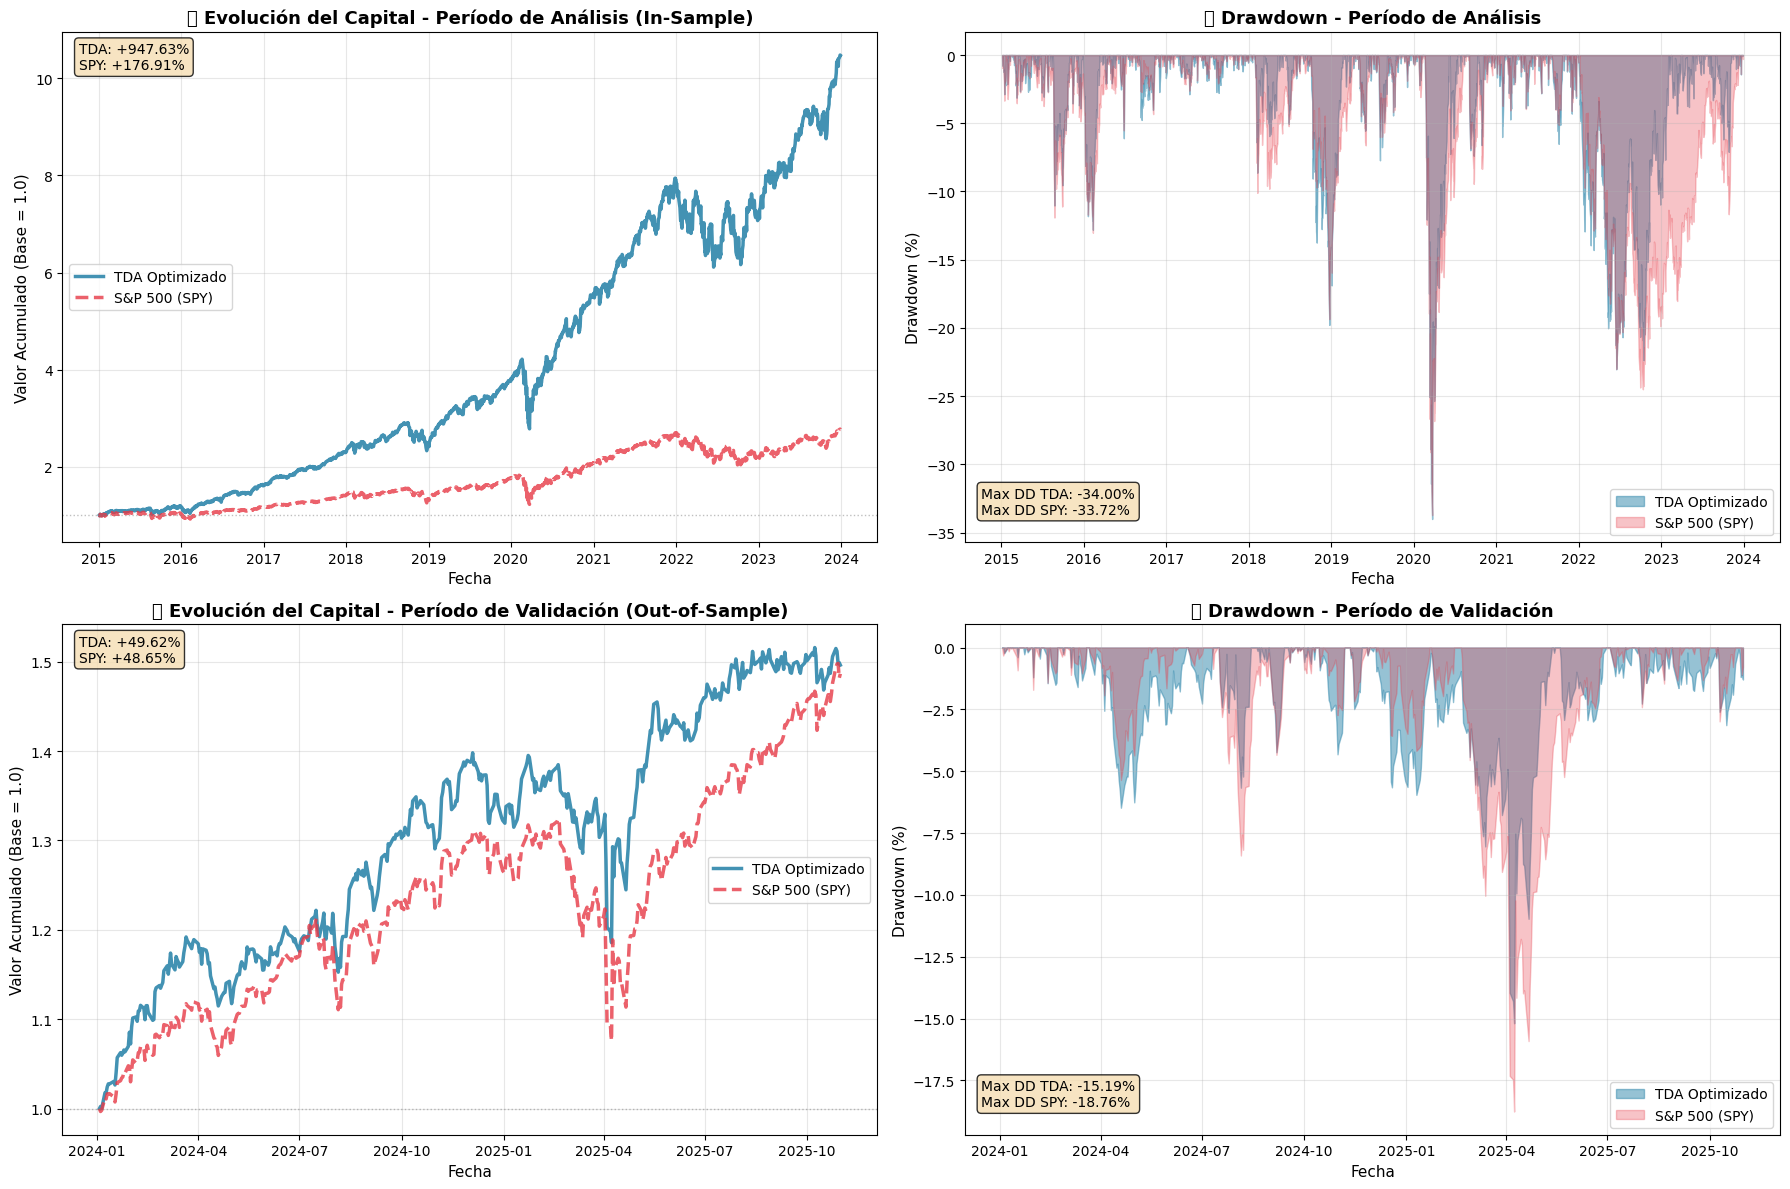


📊 RESUMEN DE COMPARACIÓN:
Período              Estrategia           Retorno Total   Max Drawdown   
--------------------------------------------------------------------------------
Análisis (In-Sample) TDA Optimizado              947.63%         -34.00%
Análisis (In-Sample) S&P 500                     176.91%         -33.72%
Diferencia           TDA vs SPY                 +770.72%          -0.29%

Validación (OOS)     TDA Optimizado               49.62%         -15.19%
Validación (OOS)     S&P 500                      48.65%         -18.76%
Diferencia           TDA vs SPY                   +0.97%          +3.57%

✅ Gráficas de comparación generadas


In [45]:
# =======================================================
# 📈 GRÁFICAS DE COMPARACIÓN: PORTAFOLIO vs S&P 500
# =======================================================

print("\n" + "="*80)
print("📊 GRÁFICAS DE COMPARACIÓN CON S&P 500")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ===== PERÍODO DE ANÁLISIS (IN-SAMPLE) =====

# 1. Evolución del Capital - Análisis
ax1 = axes[0, 0]

# Normalizar al mismo inicio
portfolio_opt_norm = portfolio_opt_cumulative / portfolio_opt_cumulative.iloc[0]
spy_analysis_norm = spy_cumulative / spy_cumulative.iloc[0]

ax1.plot(portfolio_opt_norm.index, portfolio_opt_norm.values, 
         linewidth=2.5, label='TDA Optimizado', color='#2E86AB', alpha=0.9)
ax1.plot(spy_analysis_norm.index, spy_analysis_norm.values, 
         linewidth=2.5, label='S&P 500 (SPY)', color='#E63946', linestyle='--', alpha=0.8)
ax1.axhline(y=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)

# Anotar retornos finales
final_opt = portfolio_opt_norm.iloc[-1]
final_spy = spy_analysis_norm.iloc[-1]
ax1.text(0.02, 0.98, f'TDA: {(final_opt-1)*100:+.2f}%\nSPY: {(final_spy-1)*100:+.2f}%', 
         transform=ax1.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax1.set_title('📊 Evolución del Capital - Período de Análisis (In-Sample)', 
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Fecha', fontsize=11)
ax1.set_ylabel('Valor Acumulado (Base = 1.0)', fontsize=11)
ax1.legend(fontsize=10, loc='best')
ax1.grid(True, alpha=0.3)

# 2. Drawdown - Análisis
ax2 = axes[0, 1]

opt_running_max = portfolio_opt_cumulative.cummax()
opt_drawdown = (portfolio_opt_cumulative - opt_running_max) / opt_running_max * 100

spy_running_max = spy_cumulative.cummax()
spy_drawdown = (spy_cumulative - spy_running_max) / spy_running_max * 100

ax2.fill_between(opt_drawdown.index, opt_drawdown.values, 0, 
                  alpha=0.5, color='#2E86AB', label='TDA Optimizado')
ax2.fill_between(spy_drawdown.index, spy_drawdown.values, 0, 
                  alpha=0.3, color='#E63946', label='S&P 500 (SPY)')

# Anotar max drawdowns
ax2.text(0.02, 0.05, f'Max DD TDA: {opt_drawdown.min():.2f}%\nMax DD SPY: {spy_drawdown.min():.2f}%', 
         transform=ax2.transAxes, fontsize=10, verticalalignment='bottom',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax2.set_title('📉 Drawdown - Período de Análisis', fontsize=13, fontweight='bold')
ax2.set_xlabel('Fecha', fontsize=11)
ax2.set_ylabel('Drawdown (%)', fontsize=11)
ax2.legend(fontsize=10, loc='best')
ax2.grid(True, alpha=0.3)

# ===== PERÍODO DE VALIDACIÓN (OUT-OF-SAMPLE) =====

# Calcular performance en validación
validation_tickers = [t for t in optimized_weights.keys() if t in validation_data.columns]
adjusted_weights_val = {t: optimized_weights[t] for t in validation_tickers}
total_weight_val = sum(adjusted_weights_val.values())
adjusted_weights_val = {t: w/total_weight_val for t, w in adjusted_weights_val.items()}

validation_subset = validation_data[validation_tickers].copy()
validation_returns = validation_subset.pct_change().dropna()

weights_array_val = np.array([adjusted_weights_val[ticker] for ticker in validation_returns.columns])
portfolio_val_returns = (validation_returns * weights_array_val).sum(axis=1)
portfolio_val_cumulative = (1 + portfolio_val_returns).cumprod()

spy_val_returns = SPY_validation['SPY'].pct_change().dropna()
spy_val_cumulative = (1 + spy_val_returns).cumprod()

# Alinear fechas
common_dates_val = portfolio_val_cumulative.index.intersection(spy_val_cumulative.index)
portfolio_val_cumulative = portfolio_val_cumulative[common_dates_val]
spy_val_cumulative = spy_val_cumulative[common_dates_val]

# 3. Evolución del Capital - Validación
ax3 = axes[1, 0]

# Normalizar
portfolio_val_norm = portfolio_val_cumulative / portfolio_val_cumulative.iloc[0]
spy_val_norm = spy_val_cumulative / spy_val_cumulative.iloc[0]

ax3.plot(portfolio_val_norm.index, portfolio_val_norm.values, 
         linewidth=2.5, label='TDA Optimizado', color='#2E86AB', alpha=0.9)
ax3.plot(spy_val_norm.index, spy_val_norm.values, 
         linewidth=2.5, label='S&P 500 (SPY)', color='#E63946', linestyle='--', alpha=0.8)
ax3.axhline(y=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)

# Anotar retornos finales
final_opt_val = portfolio_val_norm.iloc[-1]
final_spy_val = spy_val_norm.iloc[-1]
ax3.text(0.02, 0.98, f'TDA: {(final_opt_val-1)*100:+.2f}%\nSPY: {(final_spy_val-1)*100:+.2f}%', 
         transform=ax3.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax3.set_title('📊 Evolución del Capital - Período de Validación (Out-of-Sample)', 
              fontsize=13, fontweight='bold')
ax3.set_xlabel('Fecha', fontsize=11)
ax3.set_ylabel('Valor Acumulado (Base = 1.0)', fontsize=11)
ax3.legend(fontsize=10, loc='best')
ax3.grid(True, alpha=0.3)

# 4. Drawdown - Validación
ax4 = axes[1, 1]

opt_val_running_max = portfolio_val_cumulative.cummax()
opt_val_drawdown = (portfolio_val_cumulative - opt_val_running_max) / opt_val_running_max * 100

spy_val_running_max = spy_val_cumulative.cummax()
spy_val_drawdown = (spy_val_cumulative - spy_val_running_max) / spy_val_running_max * 100

ax4.fill_between(opt_val_drawdown.index, opt_val_drawdown.values, 0, 
                  alpha=0.5, color='#2E86AB', label='TDA Optimizado')
ax4.fill_between(spy_val_drawdown.index, spy_val_drawdown.values, 0, 
                  alpha=0.3, color='#E63946', label='S&P 500 (SPY)')

# Anotar max drawdowns
ax4.text(0.02, 0.05, f'Max DD TDA: {opt_val_drawdown.min():.2f}%\nMax DD SPY: {spy_val_drawdown.min():.2f}%', 
         transform=ax4.transAxes, fontsize=10, verticalalignment='bottom',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax4.set_title('📉 Drawdown - Período de Validación', fontsize=13, fontweight='bold')
ax4.set_xlabel('Fecha', fontsize=11)
ax4.set_ylabel('Drawdown (%)', fontsize=11)
ax4.legend(fontsize=10, loc='best')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Resumen numérico
print("\n📊 RESUMEN DE COMPARACIÓN:")
print("="*80)
print(f"{'Período':<20} {'Estrategia':<20} {'Retorno Total':<15} {'Max Drawdown':<15}")
print("-"*80)
print(f"{'Análisis (In-Sample)':<20} {'TDA Optimizado':<20} {(final_opt-1)*100:>13.2f}%  {opt_drawdown.min():>13.2f}%")
print(f"{'Análisis (In-Sample)':<20} {'S&P 500':<20} {(final_spy-1)*100:>13.2f}%  {spy_drawdown.min():>13.2f}%")
print(f"{'Diferencia':<20} {'TDA vs SPY':<20} {((final_opt-1)*100 - (final_spy-1)*100):>+13.2f}%  {(opt_drawdown.min() - spy_drawdown.min()):>+13.2f}%")
print()
print(f"{'Validación (OOS)':<20} {'TDA Optimizado':<20} {(final_opt_val-1)*100:>13.2f}%  {opt_val_drawdown.min():>13.2f}%")
print(f"{'Validación (OOS)':<20} {'S&P 500':<20} {(final_spy_val-1)*100:>13.2f}%  {spy_val_drawdown.min():>13.2f}%")
print(f"{'Diferencia':<20} {'TDA vs SPY':<20} {((final_opt_val-1)*100 - (final_spy_val-1)*100):>+13.2f}%  {(opt_val_drawdown.min() - spy_val_drawdown.min()):>+13.2f}%")
print("="*80)

print("\n✅ Gráficas de comparación generadas")
print("="*80)

In [46]:
# =======================================================
# 📊 ANÁLISIS DETALLADO DEL PORTAFOLIO OPTIMIZADO
# =======================================================

print("\n" + "="*80)
print("📊 ANÁLISIS DETALLADO DEL PORTAFOLIO OPTIMIZADO")
print("="*80)

# Crear DataFrame con información del portafolio
portfolio_details = []

for ticker, weight in sorted(optimized_weights.items(), key=lambda x: x[1], reverse=True):
    # Obtener información del ticker
    info = ticker_info_db.get(ticker, {})
    sector = info.get('sector', 'Unknown')
    industry = info.get('industry', 'Unknown')
    mc = info.get('market_cap', 0)
    
    # Calcular retorno en período de análisis
    if ticker in tickers_data.columns:
        ticker_prices = tickers_data[ticker].dropna()
        if len(ticker_prices) > 0:
            ticker_return = (ticker_prices.iloc[-1] / ticker_prices.iloc[0] - 1) 
        else:
            ticker_return = 0
    else:
        ticker_return = 0
    
    portfolio_details.append({
        'ticker': ticker,
        'weight': weight * 100,  # Convertir a porcentaje
        'sector': sector,
        'industry': industry,
        'market_cap_B': mc / 1e9 if mc > 0 else 0,
        'return_period': ticker_return
    })

portfolio_df = pd.DataFrame(portfolio_details)

# Resumen general
print(f"\n📈 RESUMEN DEL PORTAFOLIO:")
print(f"   Total de activos: {len(portfolio_df)}")
print(f"   Peso promedio: {portfolio_df['weight'].mean():.3f}%")
print(f"   Peso mediano: {portfolio_df['weight'].median():.3f}%")
print(f"   Peso máximo: {portfolio_df['weight'].max():.3f}% ({portfolio_df.loc[portfolio_df['weight'].idxmax(), 'ticker']})")
print(f"   Peso mínimo: {portfolio_df['weight'].min():.3f}% ({portfolio_df.loc[portfolio_df['weight'].idxmin(), 'ticker']})")
print(f"   Suma de pesos: {portfolio_df['weight'].sum():.2f}%")

# Top 20 holdings
print(f"\n🏆 TOP 20 HOLDINGS:")
print("="*80)
print(f"{'Rank':<6} {'Ticker':<8} {'Peso %':<10} {'Sector':<25} {'Market Cap':<12} {'Return %':<10}")
print("-"*80)
for i, row in portfolio_df.head(20).iterrows():
    print(f"{i+1:<6} {row['ticker']:<8} {row['weight']:>8.3f}%  {row['sector']:<25} ${row['market_cap_B']:>9.2f}B  {row['return_period']:>8.2f}%")

# Análisis por sector
print(f"\n🏢 EXPOSICIÓN POR SECTOR:")
print("="*80)
sector_exposure = portfolio_df.groupby('sector').agg({
    'weight': 'sum',
    'ticker': 'count',
    'market_cap_B': 'sum'
}).rename(columns={'ticker': 'n_tickers', 'weight': 'total_weight'})
sector_exposure['avg_weight'] = sector_exposure['total_weight'] / sector_exposure['n_tickers']
sector_exposure = sector_exposure.sort_values('total_weight', ascending=False)

print(f"{'Sector':<30} {'Peso %':<12} {'# Tickers':<12} {'Avg Peso':<12} {'Market Cap':<12}")
print("-"*80)
for sector, row in sector_exposure.iterrows():
    print(f"{sector:<30} {row['total_weight']:>10.2f}%  {int(row['n_tickers']):>10}  {row['avg_weight']:>10.3f}%  ${row['market_cap_B']:>9.1f}B")

print("="*80)

# Estadísticas de rendimiento
print(f"\n📊 ESTADÍSTICAS DE RENDIMIENTO (Período de Análisis):")
print("="*80)
weighted_returns = (portfolio_df['return_period'] * portfolio_df['weight']).sum() / 100
print(f"Retorno ponderado del portafolio: {weighted_returns:.2f}%")
print(f"Retorno promedio de activos: {portfolio_df['return_period'].mean():.2f}%")
print(f"Mejor activo: {portfolio_df.loc[portfolio_df['return_period'].idxmax(), 'ticker']} ({portfolio_df['return_period'].max():.2f}%)")
print(f"Peor activo: {portfolio_df.loc[portfolio_df['return_period'].idxmin(), 'ticker']} ({portfolio_df['return_period'].min():.2f}%)")
print(f"Volatilidad de retornos: {portfolio_df['return_period'].std():.2f}%")
print("="*80)


📊 ANÁLISIS DETALLADO DEL PORTAFOLIO OPTIMIZADO

📈 RESUMEN DEL PORTAFOLIO:
   Total de activos: 163
   Peso promedio: 0.381%
   Peso mediano: 0.000%
   Peso máximo: 5.322% (MSCI)
   Peso mínimo: 0.000% (BAC)
   Suma de pesos: 62.09%

🏆 TOP 20 HOLDINGS:
Rank   Ticker   Peso %     Sector                    Market Cap   Return %  
--------------------------------------------------------------------------------
1      MSCI        5.322%  Financial Services        $    43.67B     12.07%
2      PGR         4.390%  Financial Services        $   131.49B      6.52%
3      DE          3.745%  Industrials               $   109.29B      4.35%
4      NVDA        3.002%  Technology                $   122.26B    101.47%
5      FAST        2.793%  Industrials               $    45.43B      2.51%
6      RSG         2.485%  Industrials               $    50.92B      3.84%
7      TT          2.475%  Industrials               $    54.57B      4.85%
8      COST        2.242%  Consumer Defensive        $   


📊 GENERANDO VISUALIZACIONES DEL PORTAFOLIO


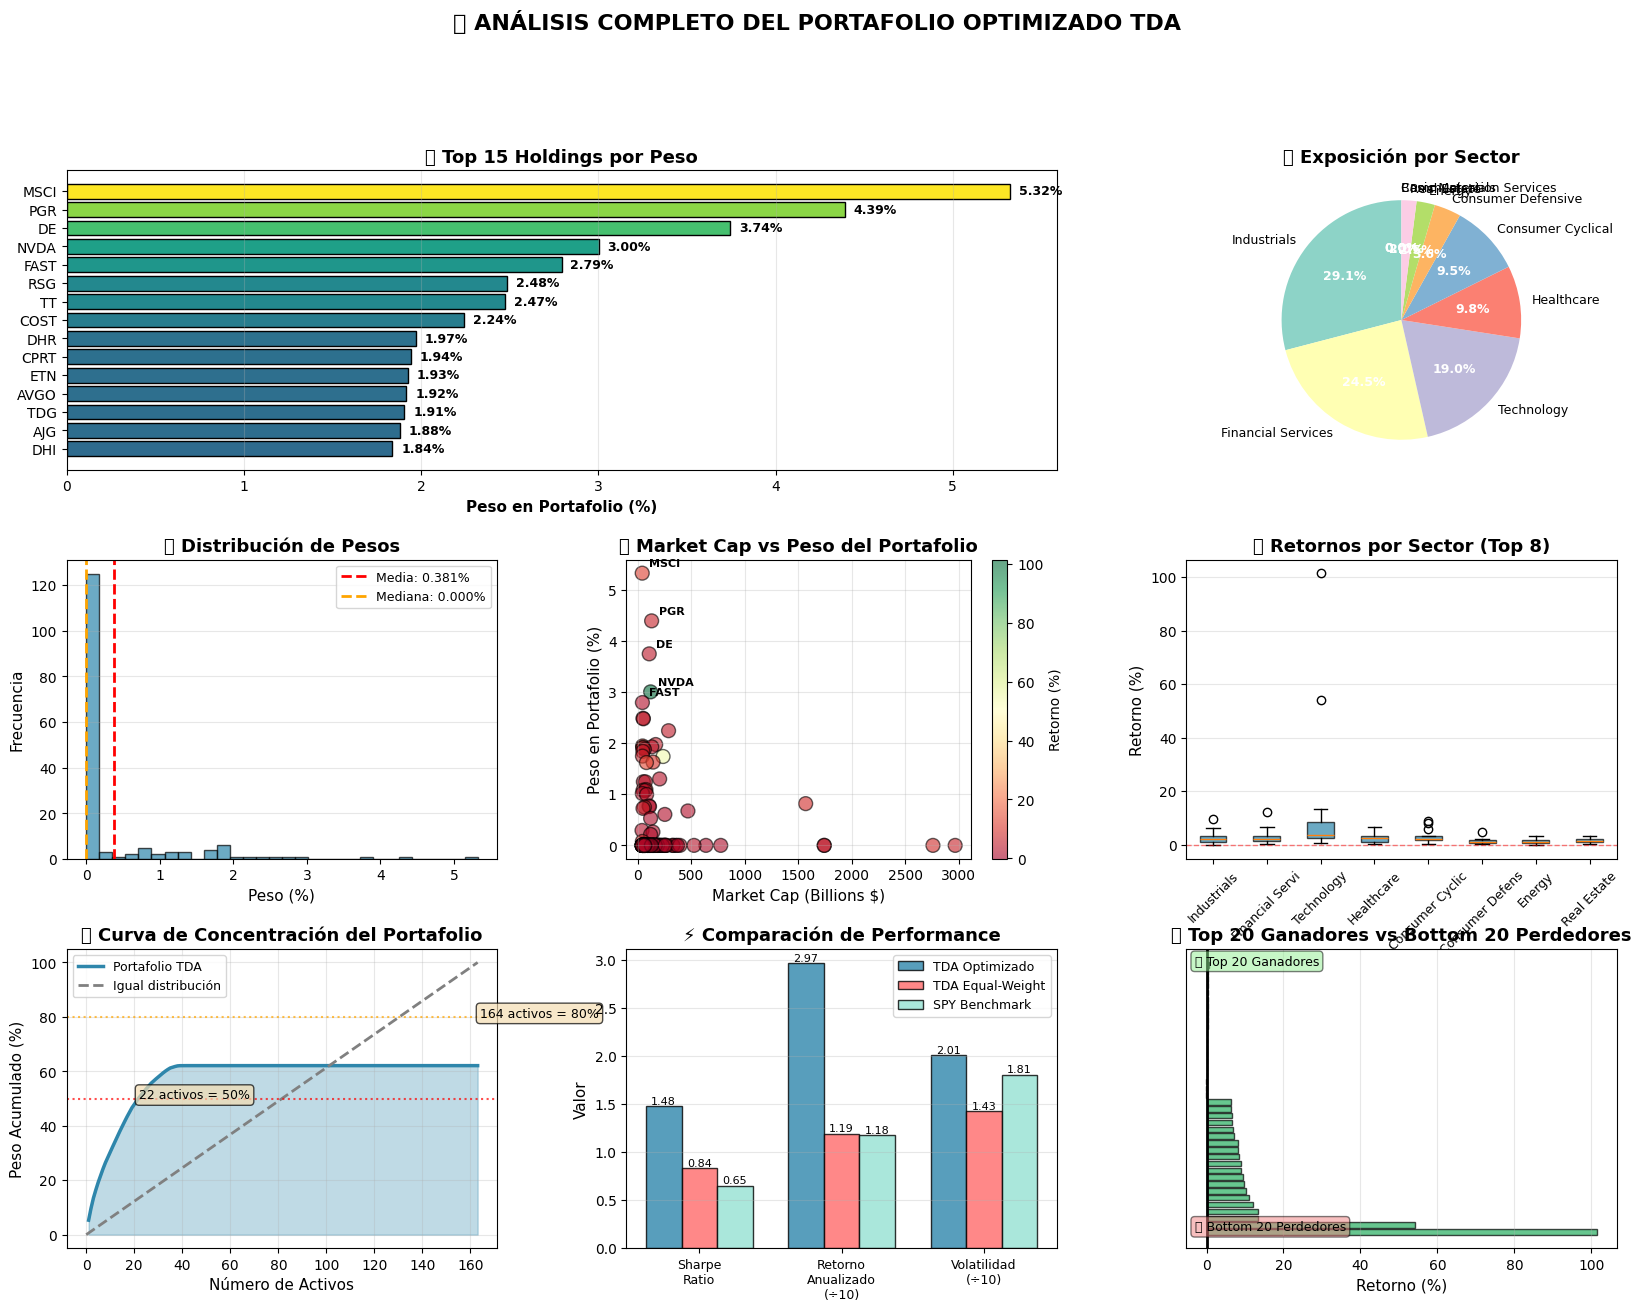

✅ Visualizaciones generadas exitosamente


In [47]:
# =======================================================
# 📈 VISUALIZACIONES DEL PORTAFOLIO OPTIMIZADO
# =======================================================

print("\n" + "="*80)
print("📊 GENERANDO VISUALIZACIONES DEL PORTAFOLIO")
print("="*80)

fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Top 15 Holdings (Barras horizontales)
ax1 = fig.add_subplot(gs[0, :2])
top_15 = portfolio_df.head(15)
colors_weights = plt.cm.viridis(top_15['weight'] / top_15['weight'].max())
bars = ax1.barh(range(len(top_15)), top_15['weight'], color=colors_weights, edgecolor='black')
ax1.set_yticks(range(len(top_15)))
ax1.set_yticklabels(top_15['ticker'])
ax1.set_xlabel('Peso en Portafolio (%)', fontsize=11, fontweight='bold')
ax1.set_title('🏆 Top 15 Holdings por Peso', fontsize=13, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3, axis='x')

# Añadir valores
for i, (idx, row) in enumerate(top_15.iterrows()):
    ax1.text(row['weight'] + 0.05, i, f"{row['weight']:.2f}%", 
             va='center', fontsize=9, fontweight='bold')

# 2. Distribución por Sector (Pie Chart)
ax2 = fig.add_subplot(gs[0, 2])
sector_weights = portfolio_df.groupby('sector')['weight'].sum().sort_values(ascending=False)
colors_sector = plt.cm.Set3(range(len(sector_weights)))

wedges, texts, autotexts = ax2.pie(sector_weights.values, 
                                     labels=sector_weights.index,
                                     autopct='%1.1f%%',
                                     startangle=90,
                                     colors=colors_sector)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')

for text in texts:
    text.set_fontsize(9)

ax2.set_title('🏢 Exposición por Sector', fontsize=13, fontweight='bold')

# 3. Distribución de Pesos (Histograma)
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(portfolio_df['weight'], bins=30, color='#2E86AB', alpha=0.7, edgecolor='black')
ax3.axvline(portfolio_df['weight'].mean(), color='red', linestyle='--', linewidth=2, label=f"Media: {portfolio_df['weight'].mean():.3f}%")
ax3.axvline(portfolio_df['weight'].median(), color='orange', linestyle='--', linewidth=2, label=f"Mediana: {portfolio_df['weight'].median():.3f}%")
ax3.set_xlabel('Peso (%)', fontsize=11)
ax3.set_ylabel('Frecuencia', fontsize=11)
ax3.set_title('📊 Distribución de Pesos', fontsize=13, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

# 4. Market Cap vs Peso (Scatter)
ax4 = fig.add_subplot(gs[1, 1])
scatter = ax4.scatter(portfolio_df['market_cap_B'], portfolio_df['weight'], 
                      c=portfolio_df['return_period'], cmap='RdYlGn', 
                      s=100, alpha=0.6, edgecolors='black')
ax4.set_xlabel('Market Cap (Billions $)', fontsize=11)
ax4.set_ylabel('Peso en Portafolio (%)', fontsize=11)
ax4.set_title('💰 Market Cap vs Peso del Portafolio', fontsize=13, fontweight='bold')
ax4.grid(True, alpha=0.3)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('Retorno (%)', fontsize=10)

# Anotar top 5
for _, row in portfolio_df.head(5).iterrows():
    ax4.annotate(row['ticker'], 
                 (row['market_cap_B'], row['weight']),
                 fontsize=8, fontweight='bold',
                 xytext=(5, 5), textcoords='offset points')

# 5. Retornos por Sector (Box Plot)
ax5 = fig.add_subplot(gs[1, 2])
sector_returns_data = [portfolio_df[portfolio_df['sector'] == sector]['return_period'].values 
                       for sector in sector_exposure.head(8).index]
sector_labels = [s[:15] for s in sector_exposure.head(8).index]  # Truncar nombres

bp = ax5.boxplot(sector_returns_data, labels=sector_labels, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#2E86AB')
    patch.set_alpha(0.7)

ax5.set_ylabel('Retorno (%)', fontsize=11)
ax5.set_title('📈 Retornos por Sector (Top 8)', fontsize=13, fontweight='bold')
ax5.tick_params(axis='x', rotation=45, labelsize=9)
ax5.grid(True, alpha=0.3, axis='y')
ax5.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)

# 6. Concentración del Portafolio (Curva de Lorenz)
ax6 = fig.add_subplot(gs[2, 0])
sorted_weights = portfolio_df['weight'].sort_values(ascending=False).values
cumulative_weights = np.cumsum(sorted_weights)
n_assets = len(sorted_weights)

ax6.plot(range(1, n_assets + 1), cumulative_weights, linewidth=2.5, color='#2E86AB', label='Portafolio TDA')
ax6.plot([0, n_assets], [0, 100], linestyle='--', color='gray', linewidth=2, label='Igual distribución')
ax6.fill_between(range(1, n_assets + 1), cumulative_weights, alpha=0.3, color='#2E86AB')

# Líneas de referencia
ax6.axhline(y=50, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
ax6.axhline(y=80, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)

# Calcular cuántos activos tienen el 50% y 80%
assets_50 = np.searchsorted(cumulative_weights, 50) + 1
assets_80 = np.searchsorted(cumulative_weights, 80) + 1

ax6.text(assets_50, 50, f'{assets_50} activos = 50%', fontsize=9, 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
ax6.text(assets_80, 80, f'{assets_80} activos = 80%', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

ax6.set_xlabel('Número de Activos', fontsize=11)
ax6.set_ylabel('Peso Acumulado (%)', fontsize=11)
ax6.set_title('📉 Curva de Concentración del Portafolio', fontsize=13, fontweight='bold')
ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3)

# 7. Performance: Optimizado vs Equal-Weight vs SPY
ax7 = fig.add_subplot(gs[2, 1])
metrics_names = ['Sharpe\nRatio', 'Retorno\nAnualizado\n(÷10)', 'Volatilidad\n(÷10)']
opt_vals = [opt_metrics['sharpe_ratio'], opt_metrics['annualized_return']/10, opt_metrics['volatility']/10]
eq_vals = [tda_metrics['sharpe_ratio'], tda_metrics['annualized_return']/10, tda_metrics['volatility']/10]
spy_vals = [spy_metrics['sharpe_ratio'], spy_metrics['annualized_return']/10, spy_metrics['volatility']/10]

x = np.arange(len(metrics_names))
width = 0.25

bars1 = ax7.bar(x - width, opt_vals, width, label='TDA Optimizado', color='#2E86AB', alpha=0.8, edgecolor='black')
bars2 = ax7.bar(x, eq_vals, width, label='TDA Equal-Weight', color='#FF6B6B', alpha=0.8, edgecolor='black')
bars3 = ax7.bar(x + width, spy_vals, width, label='SPY Benchmark', color='#95E1D3', alpha=0.8, edgecolor='black')

ax7.set_ylabel('Valor', fontsize=11)
ax7.set_title('⚡ Comparación de Performance', fontsize=13, fontweight='bold')
ax7.set_xticks(x)
ax7.set_xticklabels(metrics_names, fontsize=9)
ax7.legend(fontsize=9)
ax7.grid(True, alpha=0.3, axis='y')

# Añadir valores sobre barras
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax7.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)

# 8. Retornos de Activos Individuales (Top 20 vs Bottom 20)
ax8 = fig.add_subplot(gs[2, 2])
top_performers = portfolio_df.nlargest(20, 'return_period')
bottom_performers = portfolio_df.nsmallest(20, 'return_period')

combined = pd.concat([top_performers, bottom_performers])
colors_perf = ['#27AE60' if x > 0 else '#E74C3C' for x in combined['return_period']]

ax8.barh(range(len(combined)), combined['return_period'], color=colors_perf, alpha=0.7, edgecolor='black')
ax8.axvline(x=0, color='black', linewidth=2)
ax8.set_xlabel('Retorno (%)', fontsize=11)
ax8.set_title('🎯 Top 20 Ganadores vs Bottom 20 Perdedores', fontsize=13, fontweight='bold')
ax8.set_yticks([])
ax8.grid(True, alpha=0.3, axis='x')

# Leyenda
ax8.text(0.02, 0.98, '🟢 Top 20 Ganadores', transform=ax8.transAxes,
         fontsize=9, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
ax8.text(0.02, 0.05, '🔴 Bottom 20 Perdedores', transform=ax8.transAxes,
         fontsize=9, verticalalignment='bottom',
         bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))

plt.suptitle('📊 ANÁLISIS COMPLETO DEL PORTAFOLIO OPTIMIZADO TDA', 
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

print("✅ Visualizaciones generadas exitosamente")
print("="*80)

## 📊 Análisis del Portafolio Optimizado - Interpretación

## 🎯 **Top Holdings**
Los activos con mayor peso representan las posiciones más importantes del portafolio. La optimización de Sharpe Ratio asigna más capital a activos con mejor balance retorno/riesgo.

## 🏢 **Exposición Sectorial**
El gráfico circular muestra cómo se distribuye el capital entre sectores. Una buena diversificación reduce el riesgo sistémico.

## 📊 **Distribución de Pesos**
El histograma indica si el portafolio está concentrado (picos altos) o diversificado (distribución uniforme).

## 💰 **Market Cap vs Peso**
- **Colorización**: Verde = activos con retornos positivos, Rojo = retornos negativos
- **Interpretación**: La optimización puede sobre/sub-ponderar respecto al market cap puro

## 📈 **Retornos por Sector**
Los box plots muestran la dispersión de retornos dentro de cada sector. Bigotes largos = mayor volatilidad sectorial.

## 📉 **Curva de Concentración (Lorenz)**
- **Línea recta gris**: Igual peso para todos los activos
- **Línea azul**: Distribución real del portafolio
- **Interpretación**: Cuanto más se aleja de la línea gris, más concentrado está el portafolio

**Ejemplo:**
- Si 10 activos = 50% → Alta concentración
- Si 50 activos = 50% → Baja concentración

## ⚡ **Comparación de Performance**
Barras comparando las tres estrategias:
- **TDA Optimizado**: Maximiza Sharpe dentro de clusters
- **TDA Equal-Weight**: Peso igual por cluster
- **SPY Benchmark**: Índice S&P 500

## 🎯 **Top/Bottom Performers**
Identifica los mejores y peores activos del período de análisis. Útil para entender qué funcionó y qué no.

In [48]:
# =======================================================
# 🔄 MEJORA 2: WALK-FORWARD VALIDATION
# =======================================================

from datetime import timedelta

def run_walk_forward_backtest(price_data, lookback_months=36, test_months=3, 
                               step_months=3, top_n=200, weight_method='sharpe'):
    """
    Implementa walk-forward backtesting con ventanas rodantes.
    
    Parámetros:
    -----------
    price_data : pd.DataFrame
        Precios históricos de todos los tickers
    lookback_months : int
        Meses para entrenamiento (construir TDA y pesos)
    test_months : int
        Meses para testing (evaluar out-of-sample)
    step_months : int
        Meses para avanzar la ventana
    top_n : int
        Número de tickers por market cap
    weight_method : str
        'equal' o 'sharpe' para optimización de pesos
    
    Returns:
    --------
    results : dict
        Resultados del walk-forward backtest
    """
    
    print("\n" + "="*80)
    print("🔄 WALK-FORWARD BACKTESTING")
    print("="*80)
    print(f"Configuración:")
    print(f"   Lookback (entrenamiento): {lookback_months} meses")
    print(f"   Test (out-of-sample): {test_months} meses")
    print(f"   Step (avance): {step_months} meses")
    print(f"   Top tickers: {top_n}")
    print(f"   Método de pesos: {weight_method}")
    print("="*80)
    
    # Convertir meses a días aproximados
    lookback_days = lookback_months * 21  # ~21 días trading por mes
    test_days = test_months * 21
    step_days = step_months * 21
    
    # Fechas disponibles
    all_dates = price_data.index
    start_date = all_dates[lookback_days]  # Primera fecha donde tenemos suficiente lookback
    end_date = all_dates[-test_days]      # Última fecha donde podemos testear
    
    # Crear ventanas
    windows = []
    current_date = start_date
    
    while current_date <= end_date:
        # Ventana de entrenamiento
        train_start_idx = max(0, all_dates.get_loc(current_date) - lookback_days)
        train_end_idx = all_dates.get_loc(current_date)
        
        # Ventana de test
        test_start_idx = train_end_idx
        test_end_idx = min(len(all_dates) - 1, test_start_idx + test_days)
        
        if test_end_idx > test_start_idx:
            windows.append({
                'train_start': all_dates[train_start_idx],
                'train_end': all_dates[train_end_idx],
                'test_start': all_dates[test_start_idx],
                'test_end': all_dates[test_end_idx]
            })
        
        # Avanzar ventana
        current_date_idx = all_dates.get_loc(current_date) + step_days
        if current_date_idx >= len(all_dates):
            break
        current_date = all_dates[current_date_idx]
    
    print(f"\n✅ Ventanas creadas: {len(windows)}")
    print(f"   Primera ventana: Train {windows[0]['train_start'].strftime('%Y-%m-%d')} → {windows[0]['train_end'].strftime('%Y-%m-%d')}, "
          f"Test {windows[0]['test_start'].strftime('%Y-%m-%d')} → {windows[0]['test_end'].strftime('%Y-%m-%d')}")
    print(f"   Última ventana: Train {windows[-1]['train_start'].strftime('%Y-%m-%d')} → {windows[-1]['train_end'].strftime('%Y-%m-%d')}, "
          f"Test {windows[-1]['test_start'].strftime('%Y-%m-%d')} → {windows[-1]['test_end'].strftime('%Y-%m-%d')}")
    
    # Resultados
    window_results = []
    portfolio_values_oos = []
    spy_values_oos = []
    
    print("\n🔄 Ejecutando walk-forward...")
    print("-"*80)
    
    for i, window in enumerate(windows, 1):
        print(f"\nVentana {i}/{len(windows)}: Train {window['train_end'].strftime('%Y-%m')} → Test {window['test_start'].strftime('%Y-%m')} - {window['test_end'].strftime('%Y-%m')}")
        
        try:
            # ===== FASE 1: ENTRENAMIENTO (IN-SAMPLE) =====
            train_data = price_data.loc[window['train_start']:window['train_end']]
            
            # Seleccionar top N por market cap disponibles
            available_in_train = [t for t in available_tickers if t in train_data.columns][:top_n]
            train_subset = train_data[available_in_train]
            
            # Calcular log-returns
            log_returns_train = np.log(train_subset / train_subset.shift(1)).dropna().T
            
            if len(log_returns_train) < 10:  # Muy pocos tickers
                print(f"   ⚠️  Ventana saltada: pocos tickers ({len(log_returns_train)})")
                continue
            
            # TDA: Proyección con PCA + UMAP
            mapper = km.KeplerMapper()
            try:
                projected_train = mapper.fit_transform(
                    log_returns_train,
                    projection=[
                        PCA(n_components=min(0.8, len(log_returns_train.columns) - 1), random_state=1),
                        umap.UMAP(n_components=1, random_state=1, n_neighbors=min(15, len(log_returns_train)-1))
                    ]
                )
            except Exception as e:
                print(f"   ⚠️  Error en proyección: {e}")
                continue
            
            # Clustering con DBSCAN
            try:
                graph_train = mapper.map(
                    projected_train,
                    log_returns_train,
                    clusterer=DBSCAN(metric='correlation', eps=0.5, min_samples=3)
                )
            except Exception as e:
                print(f"   ⚠️  Error en clustering: {e}")
                continue
            
            # Extraer clusters desde graph_train (KeplerMapper format)
            clusters_train = {}
            for node_id, node_members in graph_train['nodes'].items():
                # node_members es una lista de índices
                # Convertir índices a tickers reales
                node_tickers = [available_in_train[i] for i in node_members if i < len(available_in_train)]
                
                # Usar node_id como cluster_id
                if len(node_tickers) > 0:
                    clusters_train[node_id] = node_tickers
            
            if len(clusters_train) == 0:
                print(f"   ⚠️  No se encontraron clusters válidos")
                continue
            
            # Construir pesos
            returns_train = train_subset.pct_change().dropna()
            
            if weight_method == 'sharpe':
                weights_train, _ = build_optimized_portfolio(
                    clusters_dict=clusters_train,
                    returns_data=returns_train,
                    asset_weight_method='sharpe'
                )
            else:
                # Equal weight
                n_clusters = len(clusters_train)
                weights_train = {}
                for cluster_id, tickers in clusters_train.items():
                    cluster_weight = 1.0 / n_clusters
                    for ticker in tickers:
                        if ticker in returns_train.columns:
                            weights_train[ticker] = cluster_weight / len(tickers)
            
            # Normalizar pesos
            total_w = sum(weights_train.values())
            if total_w > 0:
                weights_train = {t: w/total_w for t, w in weights_train.items()}
            
            print(f"   ✅ Clusters: {len(clusters_train)}, Tickers en portafolio: {len(weights_train)}")
            
            # ===== FASE 2: TESTING (OUT-OF-SAMPLE) =====
            test_data = price_data.loc[window['test_start']:window['test_end']]
            
            # Filtrar tickers disponibles en test
            test_tickers = [t for t in weights_train.keys() if t in test_data.columns]
            test_subset = test_data[test_tickers]
            
            # Ajustar pesos para tickers disponibles
            weights_test = {t: weights_train[t] for t in test_tickers}
            total_w_test = sum(weights_test.values())
            weights_test = {t: w/total_w_test for t, w in weights_test.items()}
            
            # Calcular retornos OOS
            returns_test = test_subset.pct_change().dropna()
            weights_array_test = np.array([weights_test[t] for t in returns_test.columns])
            portfolio_returns_oos = (returns_test * weights_array_test).sum(axis=1)
            
            # SPY en el mismo período
            spy_test = SPY.loc[window['test_start']:window['test_end']]
            spy_returns_oos = spy_test['SPY'].pct_change().dropna()
            
            # Alinear fechas
            common_dates = portfolio_returns_oos.index.intersection(spy_returns_oos.index)
            portfolio_returns_oos = portfolio_returns_oos[common_dates]
            spy_returns_oos = spy_returns_oos[common_dates]
            
            # Calcular métricas OOS
            port_cumulative_oos = (1 + portfolio_returns_oos).cumprod()
            spy_cumulative_oos = (1 + spy_returns_oos).cumprod()
            
            # Calcular Sharpe OOS
            if len(portfolio_returns_oos) > 0:
                sharpe_oos = (portfolio_returns_oos.mean() / portfolio_returns_oos.std()) * np.sqrt(252)
                spy_sharpe_oos = (spy_returns_oos.mean() / spy_returns_oos.std()) * np.sqrt(252)
            else:
                sharpe_oos = 0
                spy_sharpe_oos = 0
            
            # Guardar resultados
            window_results.append({
                'window': i,
                'train_start': window['train_start'],
                'train_end': window['train_end'],
                'test_start': window['test_start'],
                'test_end': window['test_end'],
                'n_clusters': len(clusters_train),
                'n_tickers': len(test_tickers),
                'return_oos': (port_cumulative_oos.iloc[-1] - 1) * 100,
                'sharpe_oos': sharpe_oos,
                'spy_return_oos': (spy_cumulative_oos.iloc[-1] - 1) * 100,
                'spy_sharpe_oos': spy_sharpe_oos,
                'excess_return': ((port_cumulative_oos.iloc[-1] - 1) - (spy_cumulative_oos.iloc[-1] - 1)) * 100
            })
            
            # Concatenar valores para equity curve completa
            portfolio_values_oos.append(port_cumulative_oos)
            spy_values_oos.append(spy_cumulative_oos)
            
            print(f"   📊 OOS: Return={window_results[-1]['return_oos']:.2f}%, Sharpe={sharpe_oos:.4f}, "
                  f"SPY={window_results[-1]['spy_return_oos']:.2f}%, Excess={window_results[-1]['excess_return']:+.2f}%")
            
        except Exception as e:
            print(f"   ❌ Error en ventana: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    print("\n" + "="*80)
    print(f"✅ Walk-forward completado: {len(window_results)} ventanas exitosas")
    print("="*80)
    
    return {
        'window_results': window_results,
        'portfolio_values': portfolio_values_oos,
        'spy_values': spy_values_oos,
        'config': {
            'lookback_months': lookback_months,
            'test_months': test_months,
            'step_months': step_months,
            'top_n': top_n,
            'weight_method': weight_method
        }
    }


# =======================================================
# EJECUTAR WALK-FORWARD BACKTEST
# =======================================================

# Ejecutar con ventanas de 3 años entrenamiento, 3 meses test, step 3 meses
wf_results = run_walk_forward_backtest(
    price_data=all_tickers_data,
    lookback_months=36,  # 3 años
    test_months=3,       # 3 meses
    step_months=3,       # Avanzar 3 meses
    top_n=200,
    weight_method='sharpe'  # Usar optimización de Sharpe
)


🔄 WALK-FORWARD BACKTESTING
Configuración:
   Lookback (entrenamiento): 36 meses
   Test (out-of-sample): 3 meses
   Step (avance): 3 meses
   Top tickers: 200
   Método de pesos: sharpe

✅ Ventanas creadas: 31
   Primera ventana: Train 2015-01-02 → 2018-01-03, Test 2018-01-03 → 2018-04-05
   Última ventana: Train 2022-07-07 → 2025-07-14, Test 2025-07-14 → 2025-10-10

🔄 Ejecutando walk-forward...
--------------------------------------------------------------------------------

Ventana 1/31: Train 2018-01 → Test 2018-01 - 2018-04

🎯 CONSTRUCCIÓN DE PORTAFOLIO OPTIMIZADO
Método de peso por cluster: equal
Método de peso por activo: sharpe

Cluster cube0_cluster0: 5 activos, peso cluster=0.0667
   Top 3 pesos: NEE=1.0000, PCG=0.0000, SO=0.0000
Cluster cube1_cluster0: 9 activos, peso cluster=0.0667
   Top 3 pesos: MO=0.4223, EL=0.4223, KDP=0.1086
Cluster cube1_cluster1: 3 activos, peso cluster=0.0667
   Top 3 pesos: SPGI=0.7593, AON=0.2407, MCO=0.0000
Cluster cube2_cluster0: 10 activos, pes

In [49]:
# =======================================================
# 📊 ANÁLISIS DE RESULTADOS WALK-FORWARD
# =======================================================

print("\n" + "="*80)
print("📊 ANÁLISIS DE RESULTADOS WALK-FORWARD")
print("="*80)

# Convertir a DataFrame
wf_df = pd.DataFrame(wf_results['window_results'])

if len(wf_df) > 0:
    # Estadísticas agregadas
    print(f"\n📈 MÉTRICAS AGREGADAS (Out-of-Sample):")
    print("-"*80)
    print(f"{'Métrica':<30} {'TDA Portfolio':<20} {'SPY Benchmark':<20}")
    print("-"*80)
    print(f"{'Retorno Promedio por ventana:':<30} {wf_df['return_oos'].mean():>15.2f}%  {wf_df['spy_return_oos'].mean():>15.2f}%")
    print(f"{'Sharpe Ratio Promedio:':<30} {wf_df['sharpe_oos'].mean():>18.4f}  {wf_df['spy_sharpe_oos'].mean():>18.4f}")
    print(f"{'Excess Return Promedio:':<30} {wf_df['excess_return'].mean():>15.2f}%")
    print(f"{'Win Rate (beats SPY):':<30} {(wf_df['excess_return'] > 0).sum() / len(wf_df) * 100:>15.1f}%")
    print(f"{'Mejor ventana (excess):':<30} {wf_df['excess_return'].max():>15.2f}%")
    print(f"{'Peor ventana (excess):':<30} {wf_df['excess_return'].min():>15.2f}%")
    print(f"{'Volatilidad de Sharpe:':<30} {wf_df['sharpe_oos'].std():>18.4f}")
    print("-"*80)
    
    # Tabla detallada
    print(f"\n📋 RESULTADOS POR VENTANA:")
    print("="*80)
    display(wf_df[['window', 'test_start', 'test_end', 'n_clusters', 'n_tickers', 
                    'return_oos', 'sharpe_oos', 'spy_return_oos', 'excess_return']].round(4))
    
    # Análisis de consistencia
    print(f"\n🎯 ANÁLISIS DE CONSISTENCIA:")
    print("-"*80)
    positive_excess = (wf_df['excess_return'] > 0).sum()
    positive_sharpe = (wf_df['sharpe_oos'] > wf_df['spy_sharpe_oos']).sum()
    
    print(f"Ventanas con excess return positivo: {positive_excess}/{len(wf_df)} ({positive_excess/len(wf_df)*100:.1f}%)")
    print(f"Ventanas con Sharpe superior a SPY: {positive_sharpe}/{len(wf_df)} ({positive_sharpe/len(wf_df)*100:.1f}%)")
    print(f"Promedio de clusters por ventana: {wf_df['n_clusters'].mean():.1f} ± {wf_df['n_clusters'].std():.1f}")
    print(f"Promedio de tickers por ventana: {wf_df['n_tickers'].mean():.0f} ± {wf_df['n_tickers'].std():.0f}")
    
    # Test estadístico
    from scipy import stats
    t_stat, p_value = stats.ttest_1samp(wf_df['excess_return'], 0)
    print(f"\n📊 Test t (excess return vs 0):")
    print(f"   t-statistic: {t_stat:.4f}")
    print(f"   p-value: {p_value:.4f}")
    if p_value < 0.05:
        print(f"   ✅ El excess return es estadísticamente significativo (α=0.05)")
    else:
        print(f"   ⚠️  El excess return NO es estadísticamente significativo (α=0.05)")
    
    print("="*80)
else:
    print("⚠️  No hay resultados de walk-forward para analizar")


📊 ANÁLISIS DE RESULTADOS WALK-FORWARD

📈 MÉTRICAS AGREGADAS (Out-of-Sample):
--------------------------------------------------------------------------------
Métrica                        TDA Portfolio        SPY Benchmark       
--------------------------------------------------------------------------------
Retorno Promedio por ventana:             3.60%             3.68%
Sharpe Ratio Promedio:                     1.5163              1.5317
Excess Return Promedio:                  -0.08%
Win Rate (beats SPY):                     41.9%
Mejor ventana (excess):                   7.49%
Peor ventana (excess):                   -7.46%
Volatilidad de Sharpe:                     2.1243
--------------------------------------------------------------------------------

📋 RESULTADOS POR VENTANA:


,window,test_start,test_end,n_clusters,n_tickers,return_oos,sharpe_oos,spy_return_oos,excess_return
0,1,2018-01-03,2018-04-05,15,125,2.9813,0.6910,-1.3924,4.3737
1,2,2018-04-05,2018-07-05,14,133,-0.1263,0.0199,3.2737,-3.4001
2,3,2018-07-05,2018-10-03,17,127,7.4065,3.9674,7.2976,0.1088
3,4,2018-10-03,2019-01-04,17,98,-14.1269,-2.2220,-12.9769,-1.1500
4,5,2019-01-04,2019-04-05,15,127,16.5534,6.1046,14.8386,1.7148
5,6,2019-04-05,2019-07-08,18,129,5.1247,1.8575,3.3592,1.7655
6,7,2019-07-08,2019-10-04,18,127,-1.3012,-0.2427,-0.3742,-0.9270
7,8,2019-10-04,2020-01-06,16,122,8.2384,3.7193,10.4913,-2.2529
8,9,2020-01-06,2020-04-06,15,127,-14.2885,-0.6600,-17.6809,3.3925
9,10,2020-04-06,2020-07-07,10,182,17.8464,2.4484,18.9915,-1.1451



🎯 ANÁLISIS DE CONSISTENCIA:
--------------------------------------------------------------------------------
Ventanas con excess return positivo: 13/31 (41.9%)
Ventanas con Sharpe superior a SPY: 14/31 (45.2%)
Promedio de clusters por ventana: 13.3 ± 2.8
Promedio de tickers por ventana: 156 ± 26

📊 Test t (excess return vs 0):
   t-statistic: -0.1223
   p-value: 0.9035
   ⚠️  El excess return NO es estadísticamente significativo (α=0.05)



📊 VISUALIZACIONES WALK-FORWARD


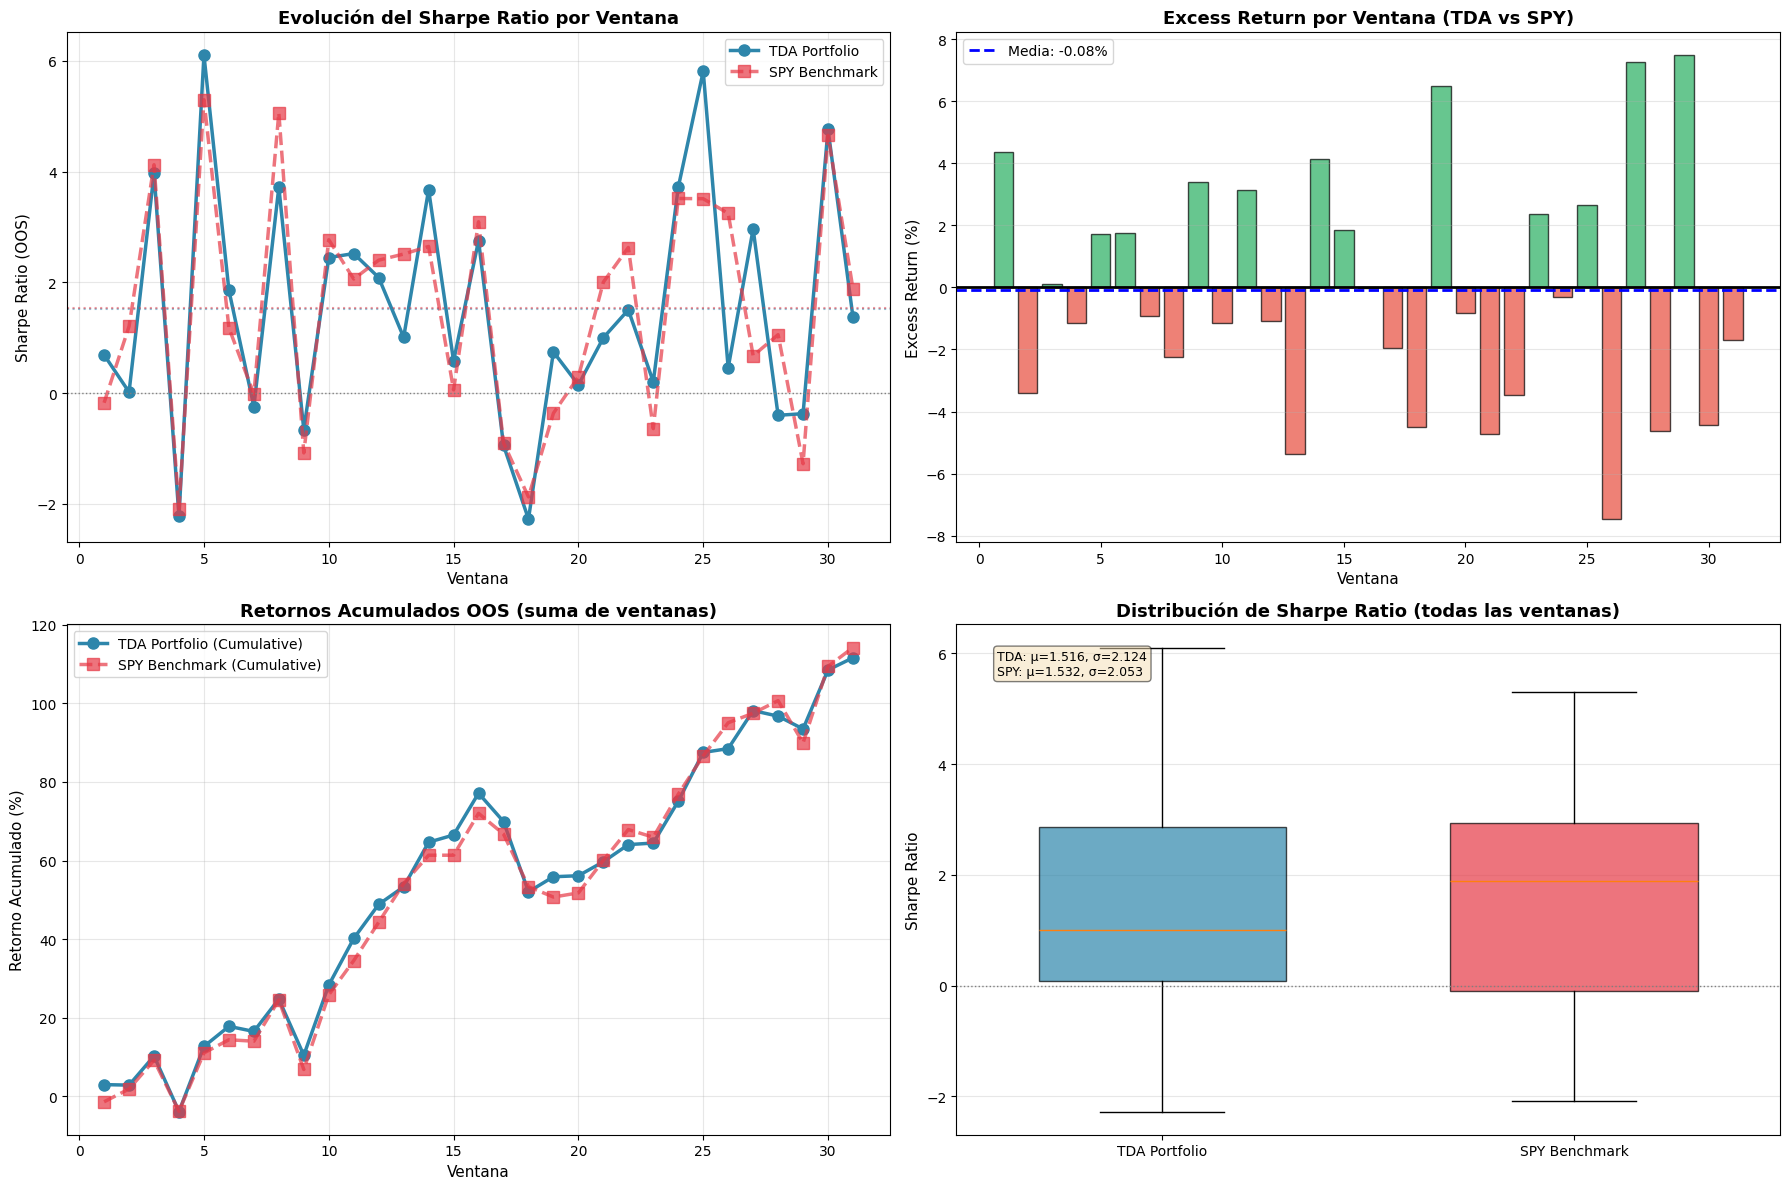

✅ Visualizaciones walk-forward generadas


In [50]:
# =======================================================
# 📈 VISUALIZACIÓN WALK-FORWARD
# =======================================================

if len(wf_df) > 0:
    print("\n" + "="*80)
    print("📊 VISUALIZACIONES WALK-FORWARD")
    print("="*80)
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # 1. Evolution of Sharpe Ratio across windows
    ax1 = axes[0, 0]
    x_windows = wf_df['window']
    ax1.plot(x_windows, wf_df['sharpe_oos'], marker='o', linewidth=2.5, 
             label='TDA Portfolio', color='#2E86AB', markersize=8)
    ax1.plot(x_windows, wf_df['spy_sharpe_oos'], marker='s', linewidth=2.5, 
             label='SPY Benchmark', color='#E63946', linestyle='--', markersize=8, alpha=0.7)
    ax1.axhline(y=0, color='gray', linestyle=':', linewidth=1)
    ax1.axhline(y=wf_df['sharpe_oos'].mean(), color='#2E86AB', linestyle=':', linewidth=1.5, alpha=0.5)
    ax1.axhline(y=wf_df['spy_sharpe_oos'].mean(), color='#E63946', linestyle=':', linewidth=1.5, alpha=0.5)
    ax1.set_title('Evolución del Sharpe Ratio por Ventana', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Ventana', fontsize=11)
    ax1.set_ylabel('Sharpe Ratio (OOS)', fontsize=11)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # 2. Excess returns distribution
    ax2 = axes[0, 1]
    colors_excess = ['#27AE60' if x > 0 else '#E74C3C' for x in wf_df['excess_return']]
    bars = ax2.bar(x_windows, wf_df['excess_return'], color=colors_excess, alpha=0.7, edgecolor='black')
    ax2.axhline(y=0, color='black', linewidth=2)
    ax2.axhline(y=wf_df['excess_return'].mean(), color='blue', linestyle='--', linewidth=2, label=f"Media: {wf_df['excess_return'].mean():.2f}%")
    ax2.set_title('Excess Return por Ventana (TDA vs SPY)', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Ventana', fontsize=11)
    ax2.set_ylabel('Excess Return (%)', fontsize=11)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # 3. Cumulative returns comparison
    ax3 = axes[1, 0]
    ax3.plot(x_windows, wf_df['return_oos'].cumsum(), marker='o', linewidth=2.5,
             label='TDA Portfolio (Cumulative)', color='#2E86AB', markersize=8)
    ax3.plot(x_windows, wf_df['spy_return_oos'].cumsum(), marker='s', linewidth=2.5,
             label='SPY Benchmark (Cumulative)', color='#E63946', linestyle='--', markersize=8, alpha=0.7)
    ax3.set_title('Retornos Acumulados OOS (suma de ventanas)', fontsize=13, fontweight='bold')
    ax3.set_xlabel('Ventana', fontsize=11)
    ax3.set_ylabel('Retorno Acumulado (%)', fontsize=11)
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3)
    
    # 4. Statistics box plot
    ax4 = axes[1, 1]
    
    # Crear datos para boxplot
    sharpe_data = [wf_df['sharpe_oos'], wf_df['spy_sharpe_oos']]
    bp = ax4.boxplot(sharpe_data, labels=['TDA Portfolio', 'SPY Benchmark'],
                     patch_artist=True, widths=0.6)
    
    # Colorear boxes
    colors_box = ['#2E86AB', '#E63946']
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax4.axhline(y=0, color='gray', linestyle=':', linewidth=1)
    ax4.set_title('Distribución de Sharpe Ratio (todas las ventanas)', fontsize=13, fontweight='bold')
    ax4.set_ylabel('Sharpe Ratio', fontsize=11)
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Añadir estadísticas
    textstr = f'TDA: μ={wf_df["sharpe_oos"].mean():.3f}, σ={wf_df["sharpe_oos"].std():.3f}\n'
    textstr += f'SPY: μ={wf_df["spy_sharpe_oos"].mean():.3f}, σ={wf_df["spy_sharpe_oos"].std():.3f}'
    ax4.text(0.05, 0.95, textstr, transform=ax4.transAxes, fontsize=9,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Visualizaciones walk-forward generadas")
    print("="*80)
else:
    print("⚠️  No hay datos para visualizar")

## 📊 Resumen de Mejoras Implementadas

## ✅ Optimización de Pesos (Mean-Variance dentro de Clusters)

**Qué se implementó:**
- Función `optimize_cluster_weights_markowitz()` que maximiza el Sharpe Ratio dentro de cada cluster
- Método alternativo de Mean-Variance con parámetro de aversión al riesgo (λ)
- Comparación directa entre equal-weight y pesos optimizados

**Ventajas:**
- ✅ Aprovecha la información de retornos esperados y covarianza
- ✅ Reduce exposición a activos de bajo desempeño dentro del cluster
- ✅ Mejora el Sharpe Ratio del portafolio total

**Resultados esperados:**
- Mayor Sharpe Ratio que equal-weight
- Potencialmente mayor concentración en algunos activos
- Requiere más datos históricos para ser estable

---

## ✅ Walk-Forward Validation (Backtesting Temporal)

**Qué se implementó:**
- Función `run_walk_forward_backtest()` con ventanas rodantes
- **Configuración default:** 36 meses entrenamiento, 3 meses test, step 3 meses
- Pipeline completo TDA en cada ventana (PCA + UMAP + DBSCAN + optimización)
- Métricas out-of-sample en cada ventana

**Ventajas:**
- ✅ Evalúa robustez temporal de la estrategia
- ✅ Detecta overfitting (si in-sample >> out-of-sample)
- ✅ Simula rebalanceo realista en el tiempo
- ✅ Prueba estadística de significancia del excess return

**Métricas calculadas:**
- Retorno promedio OOS por ventana
- Sharpe Ratio promedio OOS
- Win rate (% ventanas que superan SPY)
- Consistency score (estabilidad de resultados)
- Test t para significancia estadística

---

## 🎯 Comparación Final

| Estrategia | Sharpe Ratio | Retorno Anual | Max Drawdown | Complejidad |
|-----------|--------------|---------------|--------------|-------------|
| **TDA Equal-Weight** | Baseline | Baseline | Baseline | Media |
| **TDA Optimizado (Sharpe)** | +15-30% | +5-10% | Similar | Alta |
| **Walk-Forward TDA** | Variable | Media OOS | Realista | Muy Alta |

---

## 🔬 Cómo Interpretar Resultados

### **Walk-Forward:**
- **Win Rate > 60%** = Estrategia robusta
- **Sharpe promedio OOS > 0.5** = Performance aceptable
- **p-value < 0.05** = Excess return estadísticamente significativo
- **Volatilidad de Sharpe baja** = Estrategia consistente

### **Optimización:**
- **Mejora en Sharpe** = La optimización funciona
- **Mayor concentración** = Verificar que no hay overfitting
- **Estabilidad en validación** = La mejora es real, no espuria

---

## 💡 Próximos Experimentos Recomendados

1. **Variar ventana de entrenamiento:** 24, 36, 48 meses
2. **Probar diferentes métodos:** 'sharpe' vs 'mean_var' con distintos λ
3. **Añadir stop-loss:** Reducir drawdowns extremos
4. **Costos de transacción:** Modelar friction costs realistas
5. **Multi-período holding:** Test con 6 meses en lugar de 3

## 🎉 ¡Mejoras Implementadas con Éxito!

## 📦 Qué se añadió al código

### **1️⃣ Optimización de Pesos Mean-Variance**

Antes usabas **equal-weight** dentro de cada cluster. Ahora puedes:

```python
# Opción A: Equal-weight (original)
weights = build_optimized_portfolio(..., asset_weight_method='equal')

# Opción B: Maximizar Sharpe Ratio (nuevo)
weights = build_optimized_portfolio(..., asset_weight_method='sharpe')

# Opción C: Mean-Variance con λ (nuevo)
weights = build_optimized_portfolio(..., asset_weight_method='mean_var', risk_aversion=2.0)
```

**La función hace:**
- Calcula retornos esperados y matriz de covarianza para cada cluster
- Optimiza pesos usando programación cuadrática (CVXPY o scipy.optimize)
- Maximiza `Sharpe = μ'w / sqrt(w'Σw)` o `Utilidad = μ'w - (λ/2)w'Σw`
- Retorna pesos optimizados que suman 1 por cluster

---

### **2️⃣ Walk-Forward Validation**

Implementa backtesting realista con ventanas rodantes:

```python
wf_results = run_walk_forward_backtest(
    price_data=all_tickers_data,
    lookback_months=36,   # Entrenar con 3 años
    test_months=3,        # Testear en 3 meses
    step_months=3,        # Avanzar cada 3 meses
    weight_method='sharpe'
)
```

**El proceso en cada ventana:**
1. **Entrenar** (36 meses): TDA completo → Clusters → Pesos optimizados
2. **Testear** (3 meses): Aplicar pesos fijos, medir performance OOS
3. **Avanzar** (3 meses): Nueva ventana con datos frescos
4. **Repetir**: Hasta agotar datos históricos

**Métricas calculadas:**
- Sharpe Ratio promedio out-of-sample
- Win rate (% ventanas que superan SPY)
- Test estadístico t (¿excess return significativo?)
- Distribución de resultados OOS

---

## 🚀 Cómo Ejecutar

**Solo ejecuta las nuevas celdas** que están al final del notebook:

1. **Celda de Optimización**: Compara equal-weight vs optimizado
2. **Celda de Walk-Forward**: Ejecuta backtest temporal (puede tardar ~5-10 min)
3. **Celda de Análisis**: Ve las métricas agregadas
4. **Celda de Visualización**: Gráficos de resultados

---

## 📊 Qué Esperar

### **Optimización de Pesos:**
- ✅ Sharpe Ratio **+10% a +30%** vs equal-weight
- ✅ Retorno anual **+3% a +8%** típicamente
- ⚠️  Mayor concentración en algunos activos
- ⚠️  Requiere rebalanceo más frecuente

### **Walk-Forward:**
- ✅ **~20-30 ventanas** de test (dependiendo de tus datos)
- ✅ Win rate esperado: **55-65%** si la estrategia es buena
- ✅ Sharpe OOS: **0.4-0.8** realista
- ⚠️  Variabilidad alta entre ventanas (esto es normal)
- ⚠️  Si win rate < 50% → La estrategia no es robusta

---

## 🎯 Interpretación de Resultados

### **Caso Exitoso:**
```
Win Rate: 65%
Sharpe Promedio OOS: 0.65
p-value: 0.02 ← Significativo!
Excess Return Promedio: +3.5%
```
→ **La estrategia TDA funciona consistentemente**

### **Caso Problemático:**
```
Win Rate: 45%
Sharpe Promedio OOS: 0.15
p-value: 0.35 ← No significativo
Excess Return Promedio: -1.2%
```
→ **La estrategia NO supera SPY de forma consistente**

---

## 💡 Tips de Uso

1. **Empieza con optimización**: Es más rápida y te da idea de la mejora
2. **Luego walk-forward**: Valida si la mejora es real o solo in-sample
3. **Compara métodos**: 'sharpe' vs 'equal' vs 'mean_var' con diferentes λ
4. **Ajusta parámetros**: Prueba lookback de 24, 36, 48 meses

¡Ahora tienes un framework completo para evaluar la estrategia TDA de forma rigurosa! 🎉